### Import Or Install dependent libraries

In [1]:
# Install the libraries that are not available by default in Jupyter

#!pip install catboost
#!pip install lightgbm

In [2]:
# Import the libraries

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

### Read the datasets - Train and Test

In [3]:
# Read the input train and test housing dataset
# https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

TrainDF_HousingData = pd.read_csv(r"C:\Users\ACER\Desktop\Kranthi\DataScience_Desktop\Projects\DataMites_Projects\PRCP-1020-HousePricePred\SampleSubmissionFromKaggle\train.csv")
TestDF_HousingData = pd.read_csv(r"C:\Users\ACER\Desktop\Kranthi\DataScience_Desktop\Projects\DataMites_Projects\PRCP-1020-HousePricePred\SampleSubmissionFromKaggle\test.csv")

TestDF_HousingData.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal


### All Columns / Features information

In [4]:
# Get the shape - Get total number of Records and columns

TrainDF_HousingData.shape
# 1460 records with 81 features

(1460, 81)

In [5]:
# Get the names of all the columns in the housing data set

#HousingData_TrainDF.columns.tolist()
TrainDF_HousingData.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
# To get the names of only numeric columns

#TrainDF_HousingData.select_dtypes(include=['number']).columns.tolist()
TrainDF_HousingData.select_dtypes(include=['number']).columns

# Count the number of numerical features
# len(TrainDF_HousingData.select_dtypes(include=['number']).columns)
# len(TrainDF_HousingData.dtypes[TrainDF_HousingData.dtypes != 'object'])
# 38

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [7]:
# Get the name and data types of all the numeric features

TrainDF_HousingData.dtypes[TrainDF_HousingData.dtypes!='object']

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

In [8]:
# To get the names of only categorical columns

#TrainDF_HousingData.select_dtypes(include=['object', 'category']).columns.tolist()
TrainDF_HousingData.select_dtypes(include=['object', 'category']).columns

# Count the number of categorical features
# len(TrainDF_HousingData.select_dtypes(include=['object', 'category']).columns)
# len(TrainDF_HousingData.dtypes[TrainDF_HousingData.dtypes == 'object'])
# 43

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [9]:
# Get the name and data types of all the categorical features

TrainDF_HousingData.dtypes[TrainDF_HousingData.dtypes=='object']

MSZoning         object
Street           object
Alley            object
LotShape         object
LandContour      object
Utilities        object
LotConfig        object
LandSlope        object
Neighborhood     object
Condition1       object
Condition2       object
BldgType         object
HouseStyle       object
RoofStyle        object
RoofMatl         object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
ExterQual        object
ExterCond        object
Foundation       object
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
BsmtFinType2     object
Heating          object
HeatingQC        object
CentralAir       object
Electrical       object
KitchenQual      object
Functional       object
FireplaceQu      object
GarageType       object
GarageFinish     object
GarageQual       object
GarageCond       object
PavedDrive       object
PoolQC           object
Fence            object
MiscFeature      object
SaleType        

### Summary of all the numeric columns

In [10]:
# Display data of only numeric features

TrainDF_HousingData.select_dtypes(include=['number']).head(2)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500


In [11]:
# Summary of only numerical features

TrainDF_HousingData.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Summary of all the non-numeric columns

In [12]:
# Display data of only categorical features

TrainDF_HousingData.select_dtypes(include=['object', 'category']).head(2)

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [13]:
# Summary of only categorical features

TrainDF_HousingData.describe(include='O')

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


In [14]:
# Information about each of the columns like Column name, not null, data types...

#TrainDF_HousingData.info()

## Analysis on NULL values

<Axes: >

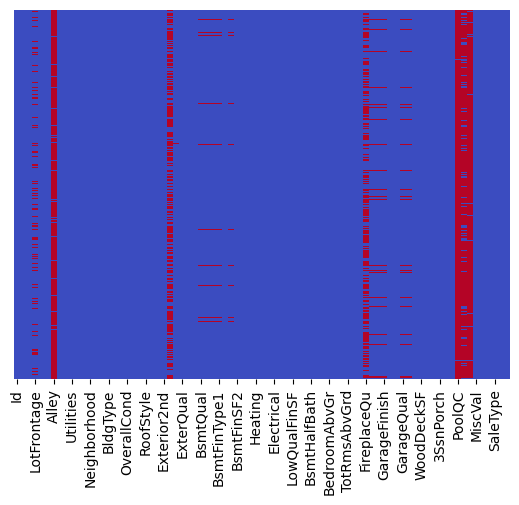

In [15]:
# Create a heatmap to visualize the nulls in the features

sns.heatmap(TrainDF_HousingData.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')

### Get the columns that have 50% of records as null values

In [16]:
# Check which columns have 50% of records as null values

for i in range(0,80):
    # Set the percentage
    percentage = 40
    
    # Get the null count of each column
    null_Count = sum(TrainDF_HousingData[TrainDF_HousingData.columns[i]].isnull())

    # Check if the null count is > 50% of the total record count
    if null_Count >= len(TrainDF_HousingData)*percentage/100:
        print('Column', TrainDF_HousingData.columns[i], 'has', null_Count, 'null values, which is greater than',percentage,'percent of total records')

    # Check which columns have records with nulls in between 5% and 50%
    #elif (null_Count > len(TrainDF_HousingData)*0.05) and (null_Count < len(TrainDF_HousingData)*0.5):
    #    print('Column', TrainDF_HousingData.columns[i], 'has', null_Count, 'null values')

Column Alley has 1369 null values, which is greater than 40 percent of total records
Column MasVnrType has 872 null values, which is greater than 40 percent of total records
Column FireplaceQu has 690 null values, which is greater than 40 percent of total records
Column PoolQC has 1453 null values, which is greater than 40 percent of total records
Column Fence has 1179 null values, which is greater than 40 percent of total records
Column MiscFeature has 1406 null values, which is greater than 40 percent of total records


In [17]:
# Get the list of columns that have nulls
# Check the null count in each column - get top 25 columns

pd.DataFrame(TrainDF_HousingData.isnull().sum().sort_values(ascending=False)).head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


### Check the distinct values and their count in each of these columns where there are nulls.

In [18]:
FeaturesWithNULLs_List = ['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu','LotFrontage','GarageQual','GarageFinish','GarageType',
                      'GarageYrBlt','GarageCond','BsmtFinType2','BsmtExposure','BsmtCond','BsmtQual','BsmtFinType1','MasVnrArea','Electrical']

for i in FeaturesWithNULLs_List:
    print('Feature',i,'has following unique values:', TrainDF_HousingData[i].unique())
    print('Total number of null values in feature',i,'are:',TrainDF_HousingData[i].isnull().sum())
    print('Count of each value in feature', TrainDF_HousingData[i].value_counts(),'\n')

Feature PoolQC has following unique values: [nan 'Ex' 'Fa' 'Gd']
Total number of null values in feature PoolQC are: 1453
Count of each value in feature PoolQC
Gd    3
Ex    2
Fa    2
Name: count, dtype: int64 

Feature MiscFeature has following unique values: [nan 'Shed' 'Gar2' 'Othr' 'TenC']
Total number of null values in feature MiscFeature are: 1406
Count of each value in feature MiscFeature
Shed    49
Gar2     2
Othr     2
TenC     1
Name: count, dtype: int64 

Feature Alley has following unique values: [nan 'Grvl' 'Pave']
Total number of null values in feature Alley are: 1369
Count of each value in feature Alley
Grvl    50
Pave    41
Name: count, dtype: int64 

Feature Fence has following unique values: [nan 'MnPrv' 'GdWo' 'GdPrv' 'MnWw']
Total number of null values in feature Fence are: 1179
Count of each value in feature Fence
MnPrv    157
GdPrv     59
GdWo      54
MnWw      11
Name: count, dtype: int64 

Feature MasVnrType has following unique values: ['BrkFace' nan 'Stone' 'Br

#### PoolQC Feature - checking on NULLs

In [19]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

TrainDF_HousingData['PoolQC'] = TrainDF_HousingData['PoolQC'].fillna('No')
TestDF_HousingData['PoolQC'] = TrainDF_HousingData['PoolQC'].fillna('No')

<Axes: xlabel='PoolQC', ylabel='SalePrice'>

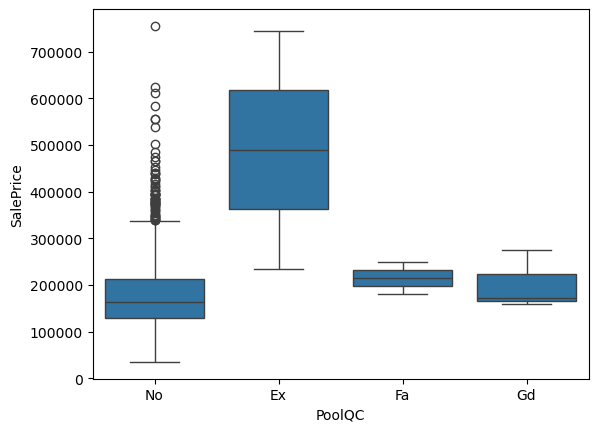

In [20]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='PoolQC',y='SalePrice',data=TrainDF_HousingData)
# PoolQC: Pool quality - Ex	Excellent, Gd	Good, TA	Average/Typical, Fa	Fair, NA	No Pool
# We can see Ex quality is having max impact on price, but even with nulls the impact is more, so we can drop this feature

#### MiscFeature Feature - Checking on NULLs

In [21]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

TrainDF_HousingData['MiscFeature'] = TrainDF_HousingData['MiscFeature'].fillna('No')
TestDF_HousingData['MiscFeature'] = TestDF_HousingData['MiscFeature'].fillna('No')

<Axes: xlabel='MiscFeature', ylabel='SalePrice'>

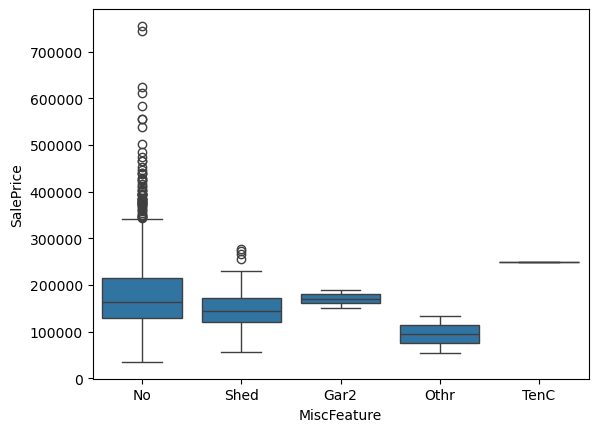

In [22]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='MiscFeature',y='SalePrice',data=TrainDF_HousingData)
# MiscFeature: Elev	Elevator, Gar2	2nd Garage (if not described in garage section), Othr	Other, Shed	Shed (over 100 SF), TenC	Tennis Court
# We can see even though Elev has max impact, no values are present and even though Shed, 2nd Garg has impact on price, 
# the price is not too high for any of the records, we can drop this feature.

#### Alley Feature - Checking on NULLs

In [23]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

TrainDF_HousingData['Alley'] = TrainDF_HousingData['Alley'].fillna('No')
TestDF_HousingData['Alley'] = TestDF_HousingData['Alley'].fillna('No')

<Axes: xlabel='Alley', ylabel='SalePrice'>

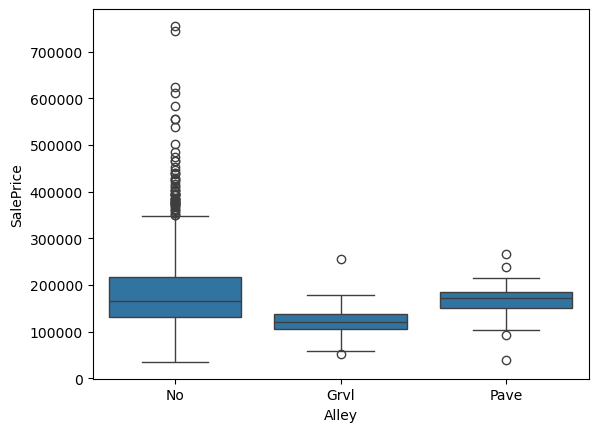

In [24]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='Alley',y='SalePrice',data=TrainDF_HousingData)
# Alley: Type of alley access to property - Grvl	Gravel, Pave	Paved, NA 	No alley access
# We can see from below graph, the properties with Alley access has no impact on high price of the property, 
# hence we can drop this feature as there are many nulls.

#### Fence Feature - Checking on NULLs

In [25]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

TrainDF_HousingData['Fence'] = TrainDF_HousingData['Fence'].fillna('No')
TestDF_HousingData['Fence'] = TestDF_HousingData['Fence'].fillna('No')

<Axes: xlabel='Fence', ylabel='SalePrice'>

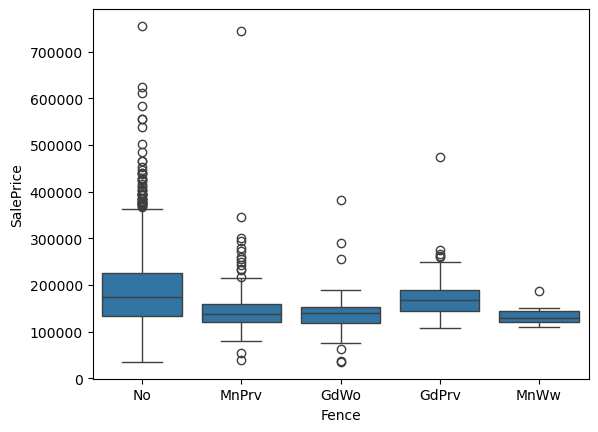

In [26]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='Fence',y='SalePrice',data=TrainDF_HousingData)
# Fence: Fence quality - GdPrv	Good Privacy, MnPrv	Minimum Privacy, GdWo	Good Wood, MnWw	Minimum Wood/Wire, NA	No Fence
# We can see Good Privacy fence is not making any impact on overall price, we can drop this feature as there are too many nulls too.

#### MasVnrType Feature - Checking on NULLs

In [27]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

'''
Total number of null values in feature MasVnrType are: 872
Count of each value in feature MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
'''

# MasVnrType: Masonry veneer type - BrkCmn	Brick Common, BrkFace	Brick Face, CBlock	Cinder Block, None	None, Stone	Stone
# We can see BrkFace has having max impact on the SalePrice compared to nulls, even Stone has impact.
# We may use this feature and see how it impacts the SalePrice.

TrainDF_HousingData['MasVnrType'] = TrainDF_HousingData['MasVnrType'].fillna('No')
TestDF_HousingData['MasVnrType'] = TestDF_HousingData['MasVnrType'].fillna('No')

<Axes: xlabel='MasVnrType', ylabel='SalePrice'>

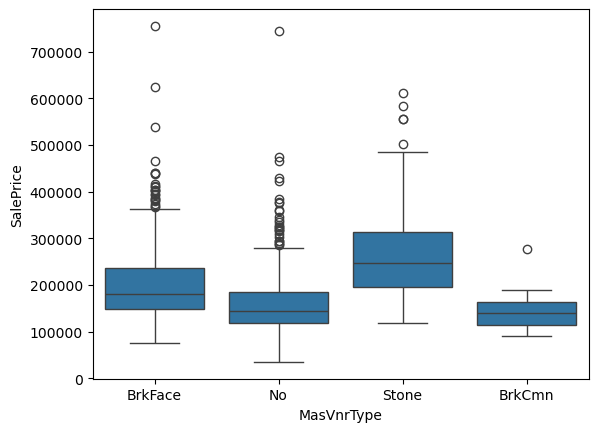

In [28]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='MasVnrType',y='SalePrice',data=TrainDF_HousingData)

#### FireplaceQu Feature - Checking on NULLs

In [29]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

# FireplaceQu: Fireplace quality
'''
       Ex	Excellent - Exceptional Masonry Fireplace
       Gd	Good - Masonry Fireplace in main level
       TA	Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
       Fa	Fair - Prefabricated Fireplace in basement
       Po	Poor - Ben Franklin Stove
       NA	No Fireplace

Count of each value in feature FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
'''
# Since NA or Null is same, let us fill nulls with No
TrainDF_HousingData['FireplaceQu'] = TrainDF_HousingData['FireplaceQu'].fillna('No')
TestDF_HousingData['FireplaceQu'] = TestDF_HousingData['FireplaceQu'].fillna('No')

<Axes: xlabel='FireplaceQu', ylabel='SalePrice'>

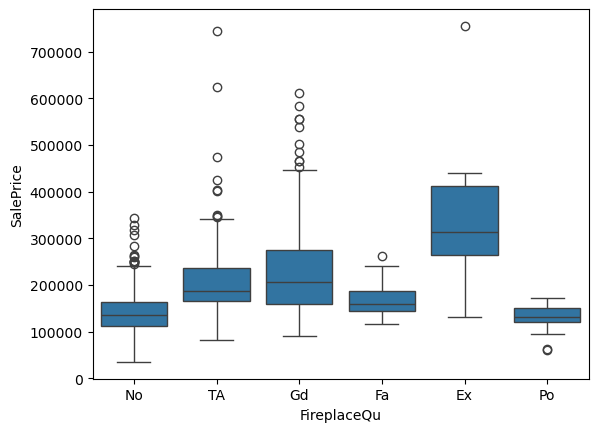

In [30]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='FireplaceQu',y='SalePrice',data=TrainDF_HousingData)
# We can see here, No has least impact on SalePrice compared to other values, we can use this feature by imputing nulls with No.

#### LotFrontage Feature - Checking on NULLs

In [31]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

#Total number of null values in feature LotFrontage are: 259

TrainDF_HousingData['LotFrontage'] = TrainDF_HousingData['LotFrontage'].fillna(0)
TestDF_HousingData['LotFrontage'] = TestDF_HousingData['LotFrontage'].fillna(0)

In [32]:
TrainDF_HousingData.query('LotFrontage.isnull()')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


<Axes: xlabel='LotFrontage', ylabel='SalePrice'>

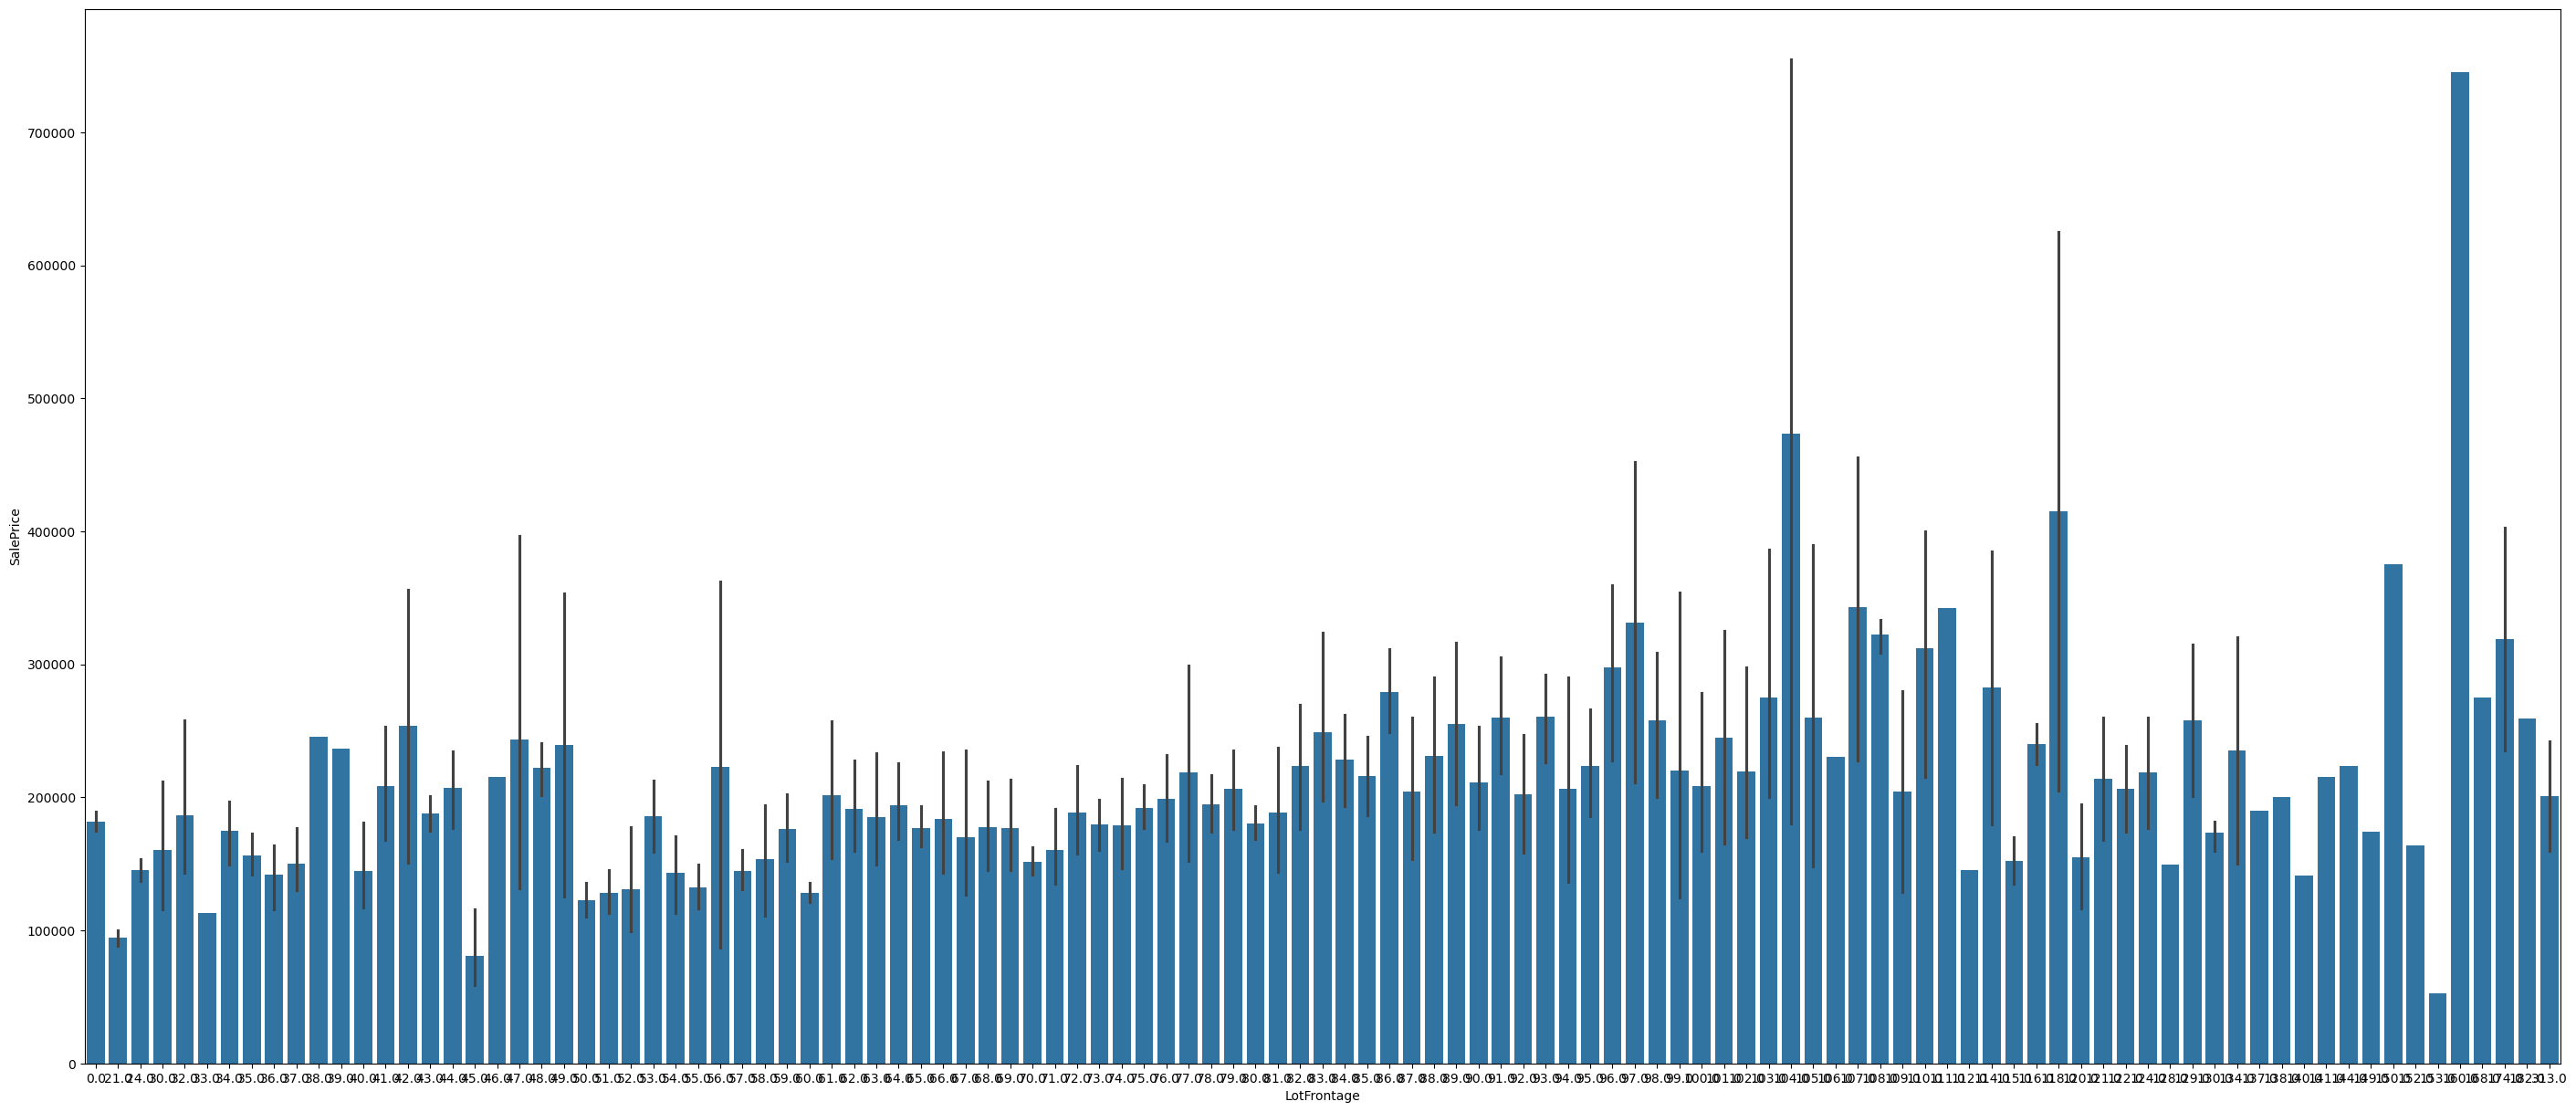

In [33]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

# LotFrontage: Linear feet of street connected to property
# Min - Maxvalues in this Feature - 0 and 313

plt.figure(figsize=(35,15))
sns.barplot(x='LotFrontage',y='SalePrice',data=TrainDF_HousingData)
# We must keep this feature, but at present imputed nulls with 0, but should we not fill with mean?

#### GarageCond Feature - Checking on NULLs

In [34]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

# Total number of null values in feature GarageCond are: 81
# TA    1326, Fa      35, Gd       9, Po       7, Ex       2

TrainDF_HousingData['GarageCond'] = TrainDF_HousingData['GarageCond'].fillna(TrainDF_HousingData['GarageCond'].mode()[0])
TestDF_HousingData['GarageCond'] = TestDF_HousingData['GarageCond'].fillna(TestDF_HousingData['GarageCond'].mode()[0])

<Axes: xlabel='GarageCond', ylabel='SalePrice'>

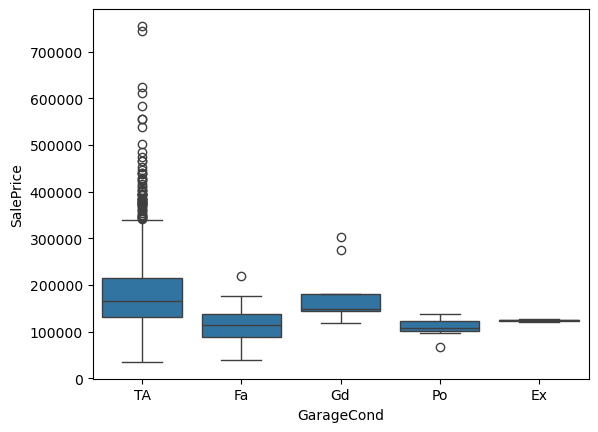

In [35]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='GarageCond',y='SalePrice',data=TrainDF_HousingData)
# GarageCond: Garage condition - Ex	Excellent, Gd	Good, TA	Typical/Average, Fa	Fair, Po	Poor, NA	No Garage
# Use this, but impute with No as No or null means no garage

#### GarageType Feature - Checking on NULLs

In [36]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

# Total number of null values in feature GarageType are: 81
# Attchd     870, Detchd     387, BuiltIn     88, Basment     19, CarPort      9, 2Types       6

# May be we should impute mode later and see?
TrainDF_HousingData['GarageType'] = TrainDF_HousingData['GarageType'].fillna('No')
TestDF_HousingData['GarageType'] = TestDF_HousingData['GarageType'].fillna('No')

<Axes: xlabel='GarageType', ylabel='SalePrice'>

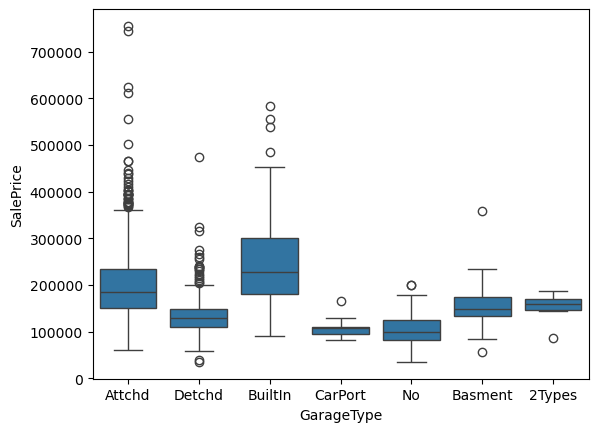

In [37]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='GarageType',y='SalePrice',data=TrainDF_HousingData)
# We can use this, but should we impute with No or Mode?

#### GarageFinish Feature - Checking on NULLs

In [38]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

# Total number of null values in feature GarageFinish are: 81
# Count of each value in feature GarageFinish - Unf    605, RFn    422, Fin    352

TrainDF_HousingData['GarageFinish'] = TrainDF_HousingData['GarageFinish'].fillna('No')
TestDF_HousingData['GarageFinish'] = TestDF_HousingData['GarageFinish'].fillna('No')

<Axes: xlabel='GarageFinish', ylabel='SalePrice'>

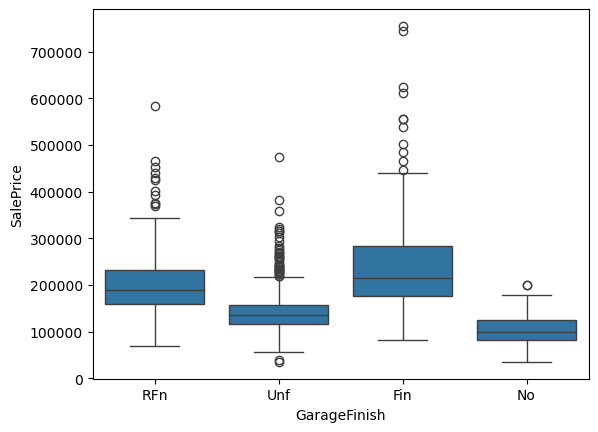

In [39]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='GarageFinish',y='SalePrice',data=TrainDF_HousingData)
# We can use this feature, but need to check if we need to impute nulls with No or Mode

#### GarageQual Feature - Checking on NULLs

In [40]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

#Total number of null values in feature GarageQual are: 81
# Count of each value in feature GarageQual - TA    1311, Fa      48, Gd      14, Ex       3, Po       3

TrainDF_HousingData['GarageQual'] = TrainDF_HousingData['GarageQual'].fillna('No')
TestDF_HousingData['GarageQual'] = TestDF_HousingData['GarageQual'].fillna('No')

<Axes: xlabel='GarageQual', ylabel='SalePrice'>

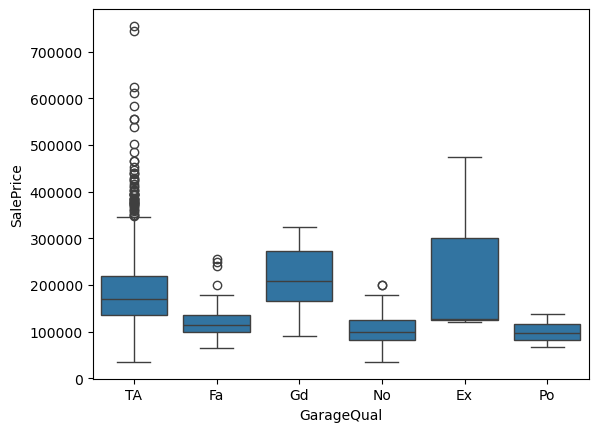

In [41]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='GarageQual',y='SalePrice',data=TrainDF_HousingData)
# We can use this feature, but need to check if we need to impute nulls with No or NULL, as null means no Garage

#### GarageYrBlt Feature - Checking on NULLs

In [42]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

# Values are ranging from 1933 - 2003 
# Total number of null values in feature GarageYrBlt are: 81

TrainDF_HousingData['GarageYrBlt'] = TrainDF_HousingData['GarageYrBlt'].fillna(0)
TestDF_HousingData['GarageYrBlt'] = TestDF_HousingData['GarageYrBlt'].fillna(0)

<Axes: xlabel='GarageYrBlt', ylabel='SalePrice'>

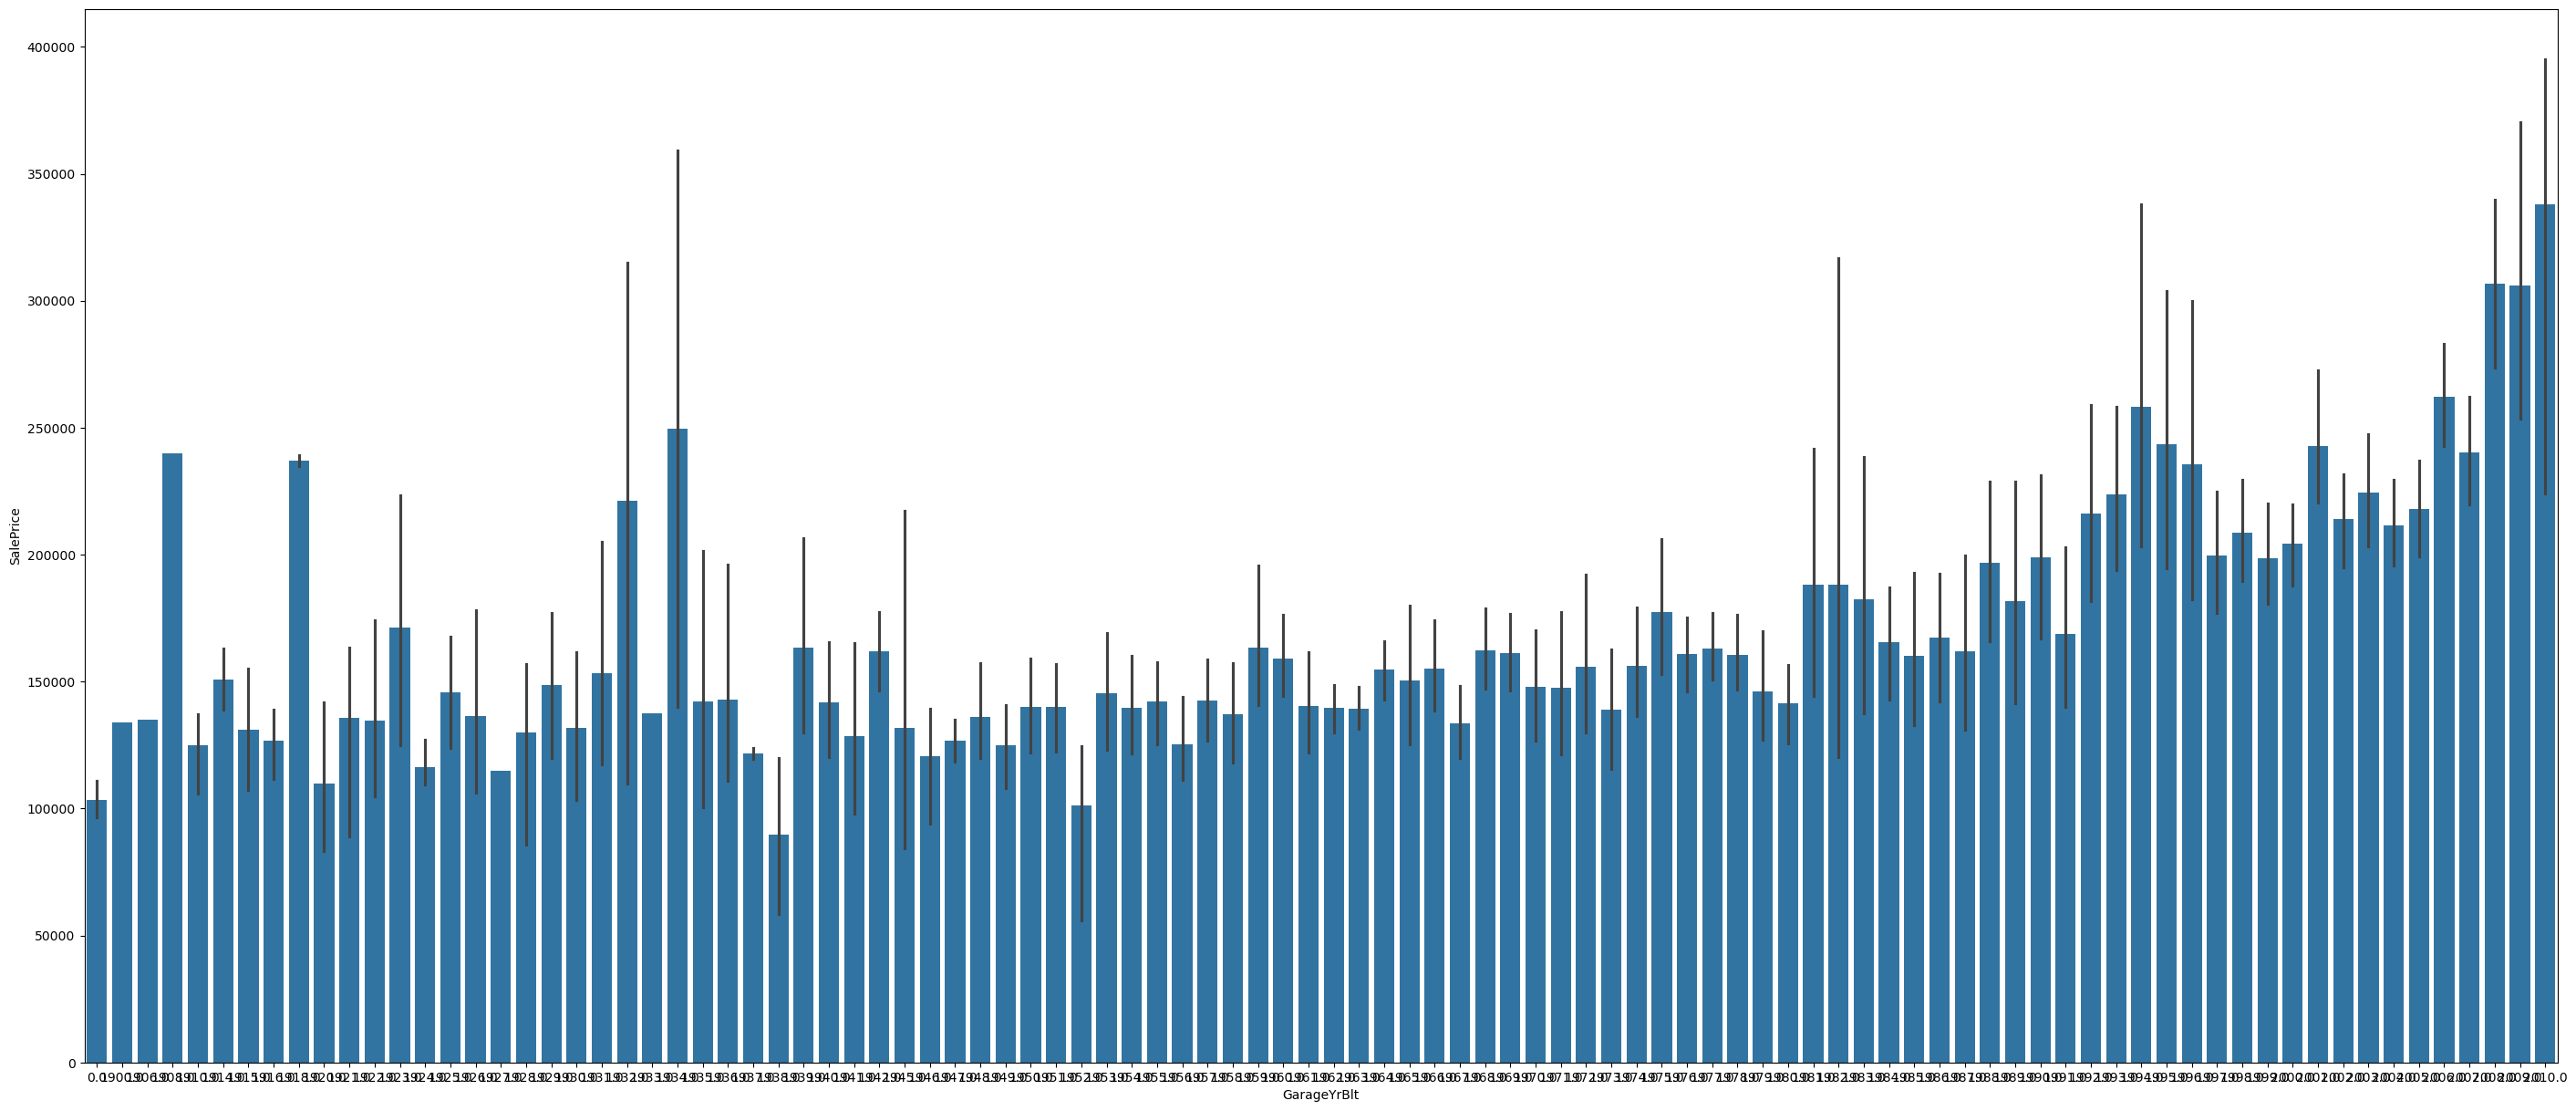

In [43]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

plt.figure(figsize=(35,15))
sns.barplot(x='GarageYrBlt',y='SalePrice',data=TrainDF_HousingData)
# Both YearBuilt and GarageYrBlt are highly corelated, may be we should ignore this feature
# or impute with mean or 0

#### BsmtFinType2 Feature - Checking on NULLs

In [44]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

# Total number of null values in feature BsmtFinType2 are: 38
# Unf    1256, Rec      54, LwQ      46, BLQ      33, ALQ      19, GLQ      14

# Since majority of the values are Unf and there are only 38 records with nulls, we can impute nulls with mode (Unf)
TrainDF_HousingData['BsmtFinType2'] = TrainDF_HousingData['BsmtFinType2'].fillna(TrainDF_HousingData['BsmtFinType2'].mode()[0])
TestDF_HousingData['BsmtFinType2'] = TestDF_HousingData['BsmtFinType2'].fillna(TestDF_HousingData['BsmtFinType2'].mode()[0])
# Since the null count is very less 38 and blank usually means unfinished/no basement and since majority of the values are unf, 
# let us impute with mode which is unf

<Axes: xlabel='BsmtFinType2', ylabel='SalePrice'>

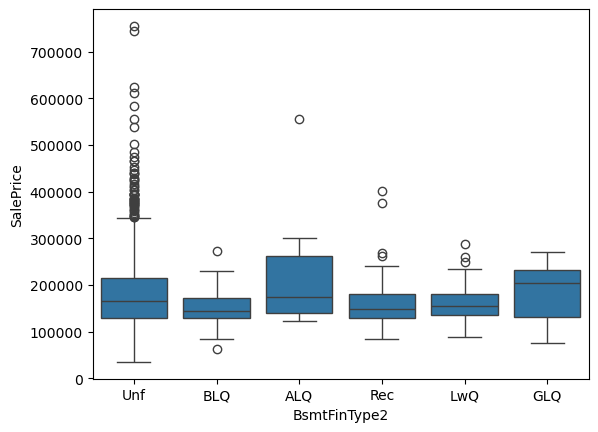

In [45]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='BsmtFinType2',y='SalePrice',data=TrainDF_HousingData)
# Since there are very few nulls and majority is no, let us impute nulls with mode

#### BsmtExposure Feature - Checking on NULLs

In [46]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

'''
Total number of null values in feature BsmtExposure are: 38
Count of each value in feature BsmtExposure
No    953
Av    221
Gd    134
Mn    114
'''

TrainDF_HousingData['BsmtExposure'] = TrainDF_HousingData['BsmtExposure'].fillna(TrainDF_HousingData['BsmtExposure'].mode()[0])
TestDF_HousingData['BsmtExposure'] = TestDF_HousingData['BsmtExposure'].fillna(TestDF_HousingData['BsmtExposure'].mode()[0])

<Axes: xlabel='BsmtExposure', ylabel='SalePrice'>

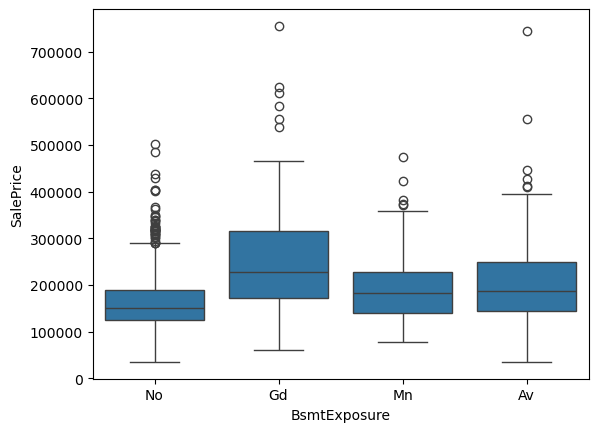

In [47]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='BsmtExposure',y='SalePrice',data=TrainDF_HousingData)
# Since there are very few nulls and majority is no, let us impute nulls with mode

#### BsmtQual Feature - Checking on NULLs

In [48]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

# Total number of null values in feature BsmtQual are: 37
# TA    649, Gd    618, Ex    121, Fa     35
# BsmtQual: Evaluates the height of the basement - Ex	Excellent (100+ inches), Gd	Good (90-99 inches), TA	Typical (80-89 inches)
# Fa	Fair (70-79 inches), Po	Poor <70 inches, NA	No Basement
# Since both TA and Gd are almost equal in number, instead of mode, let us impute with No

TrainDF_HousingData['BsmtQual'] = TrainDF_HousingData['BsmtQual'].fillna('No')
TestDF_HousingData['BsmtQual'] = TestDF_HousingData['BsmtQual'].fillna('No')

<Axes: xlabel='BsmtQual', ylabel='SalePrice'>

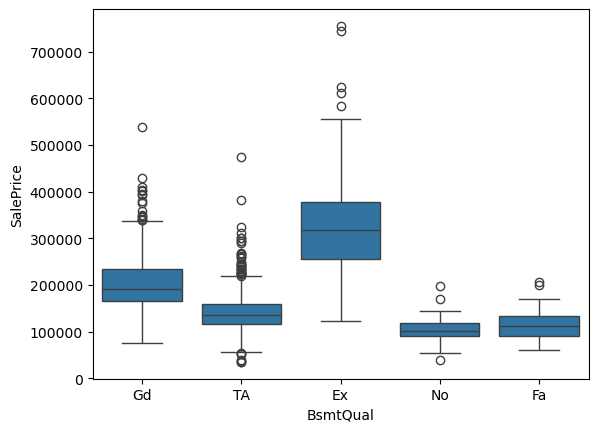

In [49]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='BsmtQual',y='SalePrice',data=TrainDF_HousingData)

#### BsmtCond Feature - Checking on NULLs

In [50]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

# Total number of null values in feature BsmtCond are: 37
# TA    1311, Gd      65, Fa      45, Po       2
# BsmtCond: Evaluates the general condition of the basement - Ex	Excellent, Gd	Good, TA	Typical - slight dampness allowed
# Fa	Fair - dampness or some cracking or settling, Po	Poor - Severe cracking, settling, or wetness, NA	No Basement
# Since majority are TA and null count is less, let us use mode

TrainDF_HousingData['BsmtCond'] = TrainDF_HousingData['BsmtCond'].fillna(TrainDF_HousingData['BsmtCond'].mode()[0])
TestDF_HousingData['BsmtCond'] = TestDF_HousingData['BsmtCond'].fillna(TestDF_HousingData['BsmtCond'].mode()[0])

<Axes: xlabel='BsmtCond', ylabel='SalePrice'>

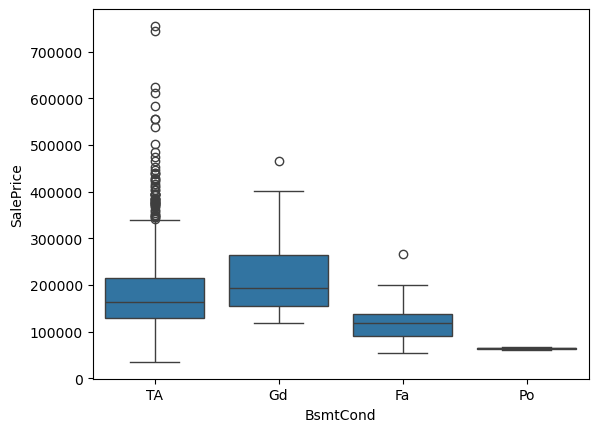

In [51]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='BsmtCond',y='SalePrice',data=TrainDF_HousingData)

#### BsmtFinType1 Feature - Checking on NULLs

In [52]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

'''
Total number of null values in feature BsmtFinType1 are: 37
Count of each value in feature BsmtFinType1
Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
'''

# Since the values are equally distributed, impute with mode (Unf or GLQ) - try both and see the impact.
TrainDF_HousingData['BsmtFinType1'] = TrainDF_HousingData['BsmtFinType1'].fillna(TrainDF_HousingData['BsmtFinType1'].mode()[0])
TestDF_HousingData['BsmtFinType1'] = TestDF_HousingData['BsmtFinType1'].fillna(TestDF_HousingData['BsmtFinType1'].mode()[0])

<Axes: xlabel='BsmtFinType1', ylabel='SalePrice'>

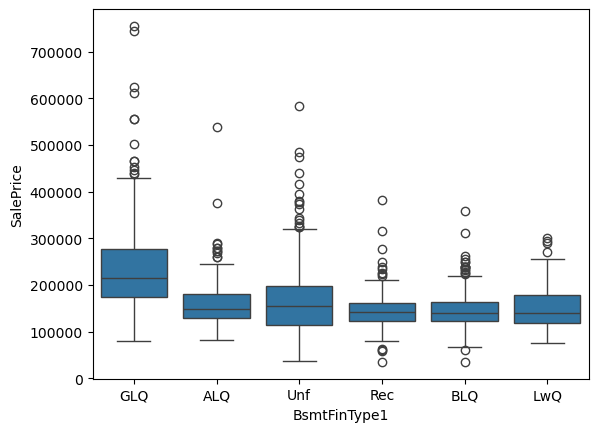

In [53]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='BsmtFinType1',y='SalePrice',data=TrainDF_HousingData)

#### MasVnrArea Feature - Checking on NULLs

In [54]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

# Total number of null values in feature MasVnrArea are: 8
# Count of each value in feature MasVnrArea
'''
0.0      861
108.0      8
72.0       8
180.0      8
... and so on...
'''

# Since this is area and there are only 8 nulls, and majority of the values in this feature are 0, let us impute nulls with 0
TrainDF_HousingData['MasVnrArea'] = TrainDF_HousingData['MasVnrArea'].fillna(0)
TestDF_HousingData['MasVnrArea'] = TestDF_HousingData['MasVnrArea'].fillna(0)

<Axes: xlabel='MasVnrArea', ylabel='SalePrice'>

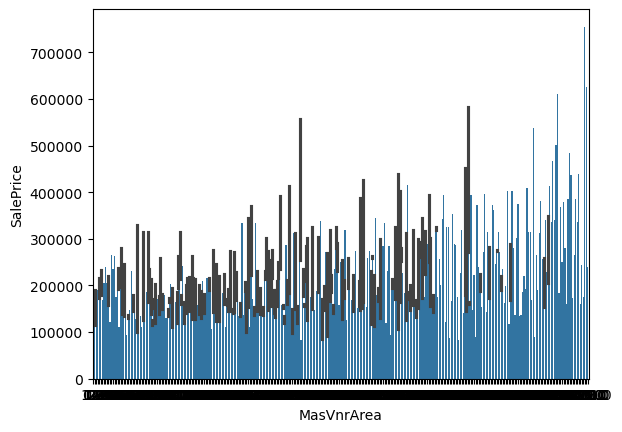

In [55]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.barplot(x='MasVnrArea',y='SalePrice',data=TrainDF_HousingData)

#### Electrical Feature - Checking on NULLs

In [56]:
# Fill the nulls with text 'No' so that nulls won't be ignored while creating the boxplot

# Total number of null values in feature Electrical are: 1
# SBrkr    1334, FuseA      94, FuseF      27, FuseP       3, Mix         1

# Since only one value is missing, let us fill with mode as the most occured value SBrkr.
TrainDF_HousingData['Electrical'] = TrainDF_HousingData['Electrical'].fillna(TrainDF_HousingData['Electrical'].mode()[0])
TestDF_HousingData['Electrical'] = TestDF_HousingData['Electrical'].fillna(TestDF_HousingData['Electrical'].mode()[0])

<Axes: xlabel='Electrical', ylabel='SalePrice'>

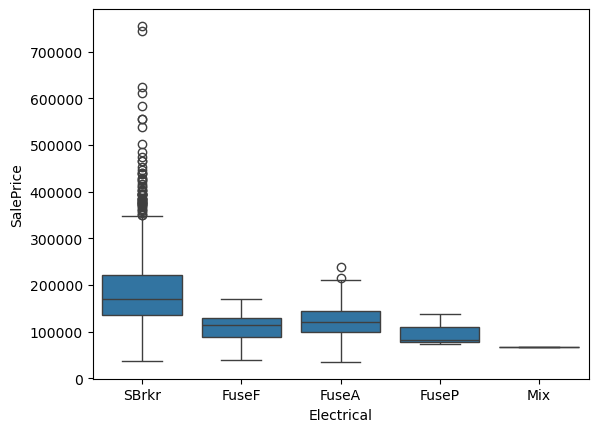

In [57]:
# Boxplot to visualize minimum, first quartile, median, third quartile, and maximum values and also to check outliers.

sns.boxplot(x='Electrical',y='SalePrice',data=TrainDF_HousingData)

## Handling NULL values
- Drop features that have more than 50% of the values as NULL
- In other features, where <50% nulls are present, Impute NULL values with mean/mode, etc. depending on the data type

In [58]:
# 50% values are NULLs in these features - Alley, PoolQC, Fence, MiscFeature

TrainDF_HousingData.drop(['Alley', 'PoolQC', 'Fence', 'MiscFeature'],axis=1,inplace = True)
TestDF_HousingData.drop(['Alley', 'PoolQC', 'Fence', 'MiscFeature'],axis=1,inplace = True)

In [59]:
# Impute with mean

TrainDF_HousingData['GarageYrBlt'] = TrainDF_HousingData['GarageYrBlt'].fillna(TrainDF_HousingData['GarageYrBlt'].mean())
TestDF_HousingData['GarageYrBlt'] = TestDF_HousingData['GarageYrBlt'].fillna(TestDF_HousingData['GarageYrBlt'].mean())
# May be we should drop this feature as this has more corelation with YearBuilt
# Do this after completing CoRelatin Analysis of all the columns.

In [60]:
# Check the CoRelation between GarageYrBlt and YearBuilt Features

TestDF_HousingData['GarageYrBlt'].corr(TestDF_HousingData['YearBuilt'])
# 0.83

np.float64(0.24787486785536453)

In [61]:
# Drop the feature

TrainDF_HousingData.drop(['GarageYrBlt'],axis=1,inplace = True)

In [62]:
# Impute with Mode
TrainDF_HousingData['GarageCond'] = TrainDF_HousingData['GarageCond'].fillna(TrainDF_HousingData['GarageCond'].mode()[0])
TestDF_HousingData['GarageCond'] = TestDF_HousingData['GarageCond'].fillna(TestDF_HousingData['GarageCond'].mode()[0])

TrainDF_HousingData['BsmtFinType2'] = TrainDF_HousingData['BsmtFinType2'].fillna(TrainDF_HousingData['BsmtFinType2'].mode()[0])
TestDF_HousingData['BsmtFinType2'] = TestDF_HousingData['BsmtFinType2'].fillna(TestDF_HousingData['BsmtFinType2'].mode()[0])

TrainDF_HousingData['Electrical'] = TrainDF_HousingData['Electrical'].fillna(TrainDF_HousingData['Electrical'].mode()[0])
TestDF_HousingData['Electrical'] = TestDF_HousingData['Electrical'].fillna(TestDF_HousingData['Electrical'].mode()[0])

TrainDF_HousingData['BsmtFinType1'] = TrainDF_HousingData['BsmtFinType1'].fillna(TrainDF_HousingData['BsmtFinType1'].mode()[0])
TestDF_HousingData['BsmtFinType1'] = TestDF_HousingData['BsmtFinType1'].fillna(TestDF_HousingData['BsmtFinType1'].mode()[0])
# Once try with GLQ, instead of mode value Unf

TrainDF_HousingData['BsmtCond'] = TrainDF_HousingData['BsmtCond'].fillna(TrainDF_HousingData['BsmtCond'].mode()[0])
TestDF_HousingData['BsmtCond'] = TestDF_HousingData['BsmtCond'].fillna(TestDF_HousingData['BsmtCond'].mode()[0])
# Once try with No instead of mode value TA

TrainDF_HousingData['BsmtExposure'] = TrainDF_HousingData['BsmtExposure'].fillna(TrainDF_HousingData['BsmtExposure'].mode()[0])
TestDF_HousingData['BsmtExposure'] = TestDF_HousingData['BsmtExposure'].fillna(TestDF_HousingData['BsmtExposure'].mode()[0])
# Once try with No

In [63]:
# Impute with 'No' instead of Mode - Later use Mode changes
TrainDF_HousingData['GarageType'] = TrainDF_HousingData['GarageType'].fillna('No')
TestDF_HousingData['GarageType'] = TestDF_HousingData['GarageType'].fillna('No')
# Try with Mode

TrainDF_HousingData['GarageFinish'] = TrainDF_HousingData['GarageFinish'].fillna('No')
TestDF_HousingData['GarageFinish'] = TestDF_HousingData['GarageFinish'].fillna('No')
# Try with Mode

TrainDF_HousingData['GarageQual'] = TrainDF_HousingData['GarageQual'].fillna('No')
TestDF_HousingData['GarageQual'] = TestDF_HousingData['GarageQual'].fillna('No')
# Try with mode

TrainDF_HousingData['MasVnrType'] = TrainDF_HousingData['MasVnrType'].fillna('No')
TestDF_HousingData['MasVnrType'] = TestDF_HousingData['MasVnrType'].fillna('No')
# Even though MasVnrType has 50% values as nulls, let us utilize this feature as not null haves are having more impact on the SalePrice

TrainDF_HousingData['BsmtQual'] = TrainDF_HousingData['BsmtQual'].fillna('No')
TestDF_HousingData['BsmtQual'] = TestDF_HousingData['BsmtQual'].fillna('No')
# Since BsmtCond is imputed with mode, once try with mode and see how it impacts

TrainDF_HousingData['FireplaceQu'] = TrainDF_HousingData['FireplaceQu'].fillna('No')
TestDF_HousingData['FireplaceQu'] = TestDF_HousingData['FireplaceQu'].fillna('No')
# FireplaceQu - 40% of values are nulls???

In [64]:
# Impute with 0 instead of Mean - Later use Mean and see how the score changes
TrainDF_HousingData['MasVnrArea'] = TrainDF_HousingData['MasVnrArea'].fillna(0)
TestDF_HousingData['MasVnrArea'] = TestDF_HousingData['MasVnrArea'].fillna(0)
# Try with mean

TrainDF_HousingData['LotFrontage'] = TrainDF_HousingData['LotFrontage'].fillna(0)
TestDF_HousingData['LotFrontage'] = TestDF_HousingData['LotFrontage'].fillna(0)
# Try with mean

### Validate if there are NULLs after drop/impute

<Axes: >

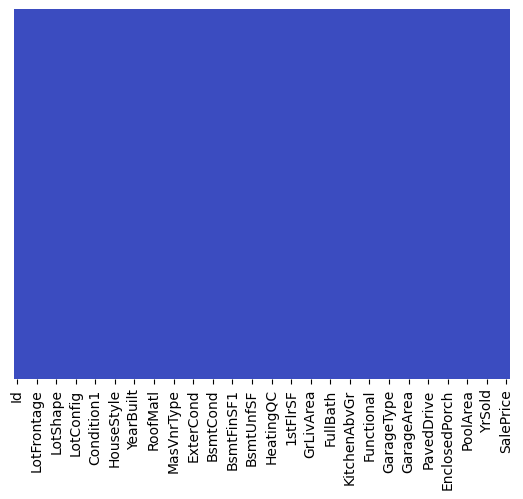

In [65]:
# Heatmap to check if there are still nulls after imputing

sns.heatmap(TrainDF_HousingData.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')
# We can see all the nulls are filled appropriately

# Feature/ Column wise analysis
- Check for outliers using the Scatterplot, it also helps to understand how the feature is directly impacting the SalesPrice.

## MSSubClass Feature

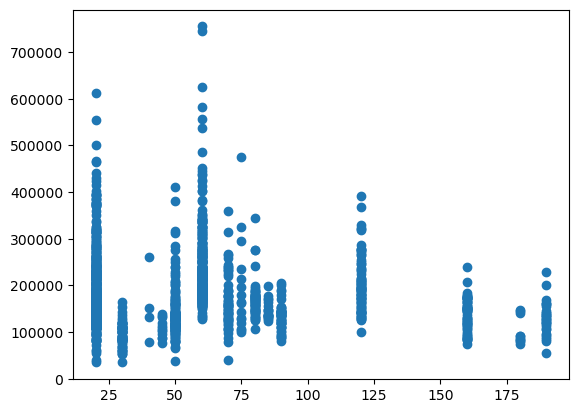

In [66]:
# Draw a scatterplot to see the relationship between MSSubClass Feature and Output feature(SalePrice)

plt.scatter(x = 'MSSubClass', y = 'SalePrice', data = TrainDF_HousingData)

In [67]:
# Check the records with very high Sale price 

TrainDF_HousingData.query('MSSubClass == 60 and SalePrice > 500000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,0,0,1,2007,WD,Normal,755000
769,770,60,RL,47.0,53504,Pave,IR2,HLS,AllPub,CulDSac,...,0,0,210,0,0,6,2010,WD,Normal,538000
803,804,60,RL,107.0,13891,Pave,Reg,Lvl,AllPub,Inside,...,0,0,192,0,0,1,2009,New,Partial,582933
1046,1047,60,RL,85.0,16056,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,7,2006,New,Partial,556581
1169,1170,60,RL,118.0,35760,Pave,IR1,Lvl,AllPub,CulDSac,...,0,0,0,0,0,7,2006,WD,Normal,625000
1182,1183,60,RL,160.0,15623,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,555,0,7,2007,WD,Abnorml,745000


## MSZoning Feature

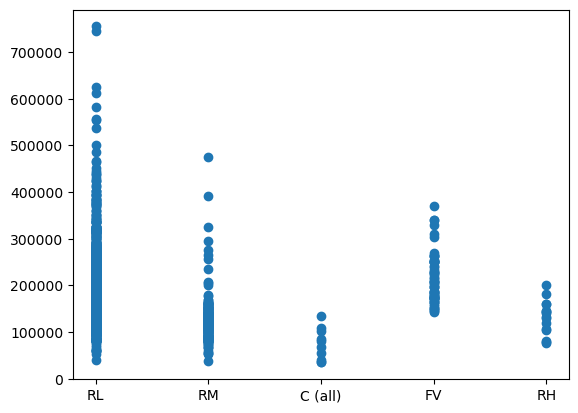

In [68]:
plt.scatter(x = 'MSZoning', y = 'SalePrice',data = TrainDF_HousingData)

In [69]:
TrainDF_HousingData.query('MSZoning == "RL" and SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,0,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,555,0,7,2007,WD,Abnorml,745000


## LotFrontage Feature

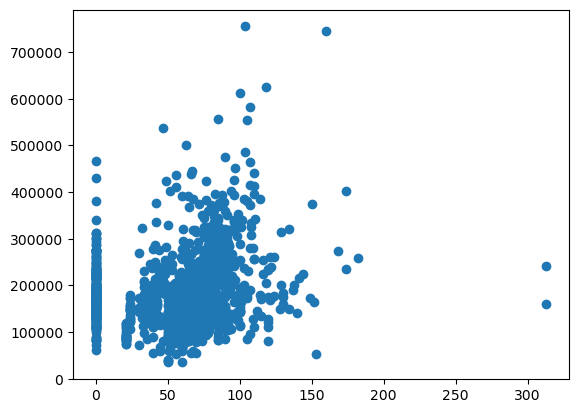

In [70]:
# Plot a scatterplot to get the visualation of the feature 

plt.scatter(x = 'LotFrontage', y = 'SalePrice', data = TrainDF_HousingData)

In [71]:
# Find value lotFrontage when the sale price is maximum

TrainDF_HousingData.query('LotFrontage > 50 and LotFrontage < 170 and SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,0,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,555,0,7,2007,WD,Abnorml,745000


In [72]:
# Check outliers in lotFrontage

TrainDF_HousingData.query('LotFrontage > 190')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
934,935,20,RL,313.0,27650,Pave,IR2,HLS,AllPub,Inside,...,0,0,0,0,0,11,2008,WD,Normal,242000
1298,1299,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,...,0,0,0,480,0,1,2008,New,Partial,160000


## BsmtCond Feature

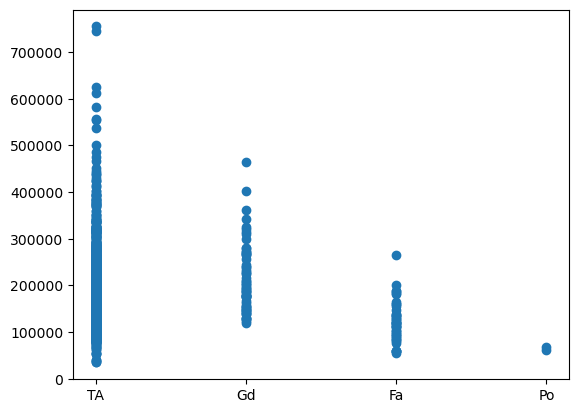

In [73]:
# Plot a scatterplot to get the visualation of the feature 

plt.scatter(x = 'BsmtCond', y = 'SalePrice', data = TrainDF_HousingData)

## BsmtQual Feature

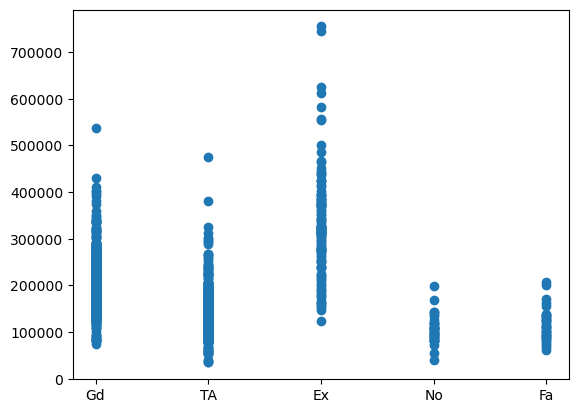

In [74]:
# Plot a scatterplot to get the visualation of the feature 

plt.scatter(x = 'BsmtQual', y = 'SalePrice', data = TrainDF_HousingData)

## LotArea Feature

In [75]:
# Check total number of unique values
len(TrainDF_HousingData.LotArea.unique())
# 1073

TrainDF_HousingData.LotArea.min()
#1,300 sft

TrainDF_HousingData.LotArea.max()
#2,15,245 sft

# This usually should be directly proportional to the sale price

215245

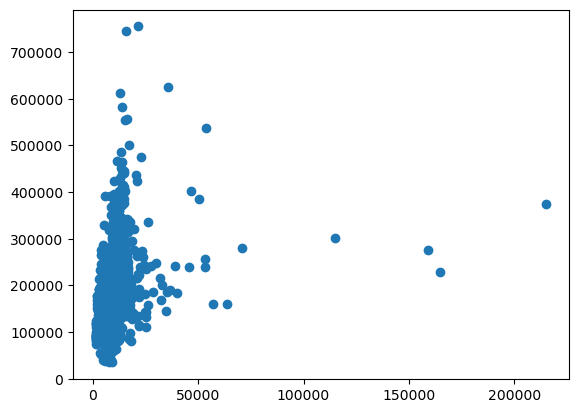

In [76]:
plt.scatter(x = 'LotArea', y = 'SalePrice', data = TrainDF_HousingData)

In [77]:
# Find value LotArea when the sale price is maximum

TrainDF_HousingData.query('LotArea > 1300 and LotArea < 50000 and SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,0,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,555,0,7,2007,WD,Abnorml,745000


In [78]:
# Check for outliers

TrainDF_HousingData.query('LotArea > 75000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
249,250,50,RL,0.0,159000,Pave,IR2,Low,AllPub,CulDSac,...,0,0,0,0,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,IR3,Low,AllPub,Inside,...,0,0,0,0,0,6,2009,WD,Normal,375000
335,336,190,RL,0.0,164660,Grvl,IR1,HLS,AllPub,Corner,...,0,0,0,0,700,8,2008,WD,Normal,228950
706,707,20,RL,0.0,115149,Pave,IR2,Low,AllPub,CulDSac,...,0,0,0,0,0,6,2007,WD,Normal,302000


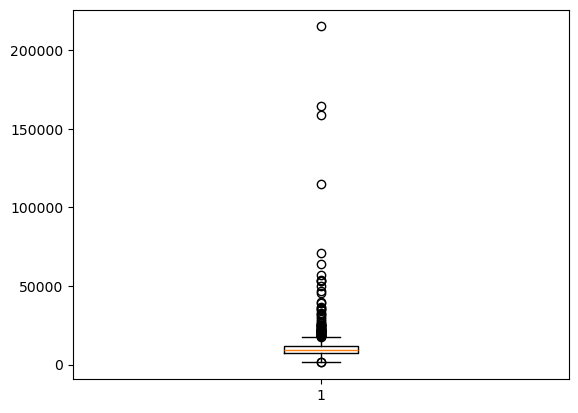

In [79]:
# Box plot to check for outliers

plt.boxplot(TrainDF_HousingData.LotArea)
plt.show()

In [80]:
# ZScore to find the outliers

pd.Series(stats.zscore(TrainDF_HousingData['LotArea'])).sort_values().tail(5)

451     6.037793
706    10.486449
249    14.881285
335    15.448542
313    20.518273
dtype: float64

In [81]:
# Manual way to find out the outliers

Mean = TrainDF_HousingData.LotArea.mean()
SD = TrainDF_HousingData.LotArea.std()
Highest_Allowed_Value = Mean + (3*SD)
# 40460.62287932922
Lowest_Allowed_Value = Mean - (3*SD)
# -19426.966714945658

In [82]:
# Outliers as per the manul calculation

TrainDF_HousingData.query('LotArea < -19426.966714945658')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


In [83]:
# Outliers as per the manul calculation

TrainDF_HousingData.query('LotArea > 40460.62287932922')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
53,54,20,RL,68.0,50271,Pave,IR1,Low,AllPub,Inside,...,0,0,0,0,0,11,2006,WD,Normal,385000
249,250,50,RL,0.0,159000,Pave,IR2,Low,AllPub,CulDSac,...,0,0,0,0,500,6,2007,WD,Normal,277000
313,314,20,RL,150.0,215245,Pave,IR3,Low,AllPub,Inside,...,0,0,0,0,0,6,2009,WD,Normal,375000
335,336,190,RL,0.0,164660,Grvl,IR1,HLS,AllPub,Corner,...,0,0,0,0,700,8,2008,WD,Normal,228950
384,385,60,RL,0.0,53107,Pave,IR2,Low,AllPub,Corner,...,0,0,0,0,0,6,2007,WD,Normal,240000
451,452,20,RL,62.0,70761,Pave,IR1,Low,AllPub,Inside,...,0,0,0,0,0,12,2006,WD,Normal,280000
457,458,20,RL,0.0,53227,Pave,IR1,Low,AllPub,CulDSac,...,0,0,0,0,0,3,2008,WD,Normal,256000
661,662,60,RL,52.0,46589,Pave,IR2,Lvl,AllPub,CulDSac,...,0,0,0,0,0,7,2009,WD,Normal,402000
706,707,20,RL,0.0,115149,Pave,IR2,Low,AllPub,CulDSac,...,0,0,0,0,0,6,2007,WD,Normal,302000
769,770,60,RL,47.0,53504,Pave,IR2,HLS,AllPub,CulDSac,...,0,0,210,0,0,6,2010,WD,Normal,538000


## FireplaceQu Feature

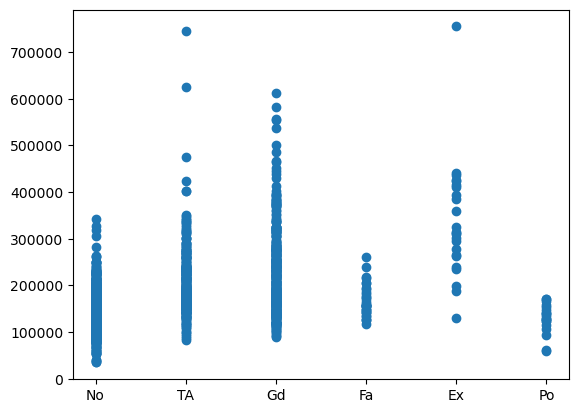

In [84]:
# Plot a scatterplot to get the visualation of the feature 

plt.scatter(x = 'FireplaceQu', y = 'SalePrice', data = TrainDF_HousingData)

## GarageType Feature 

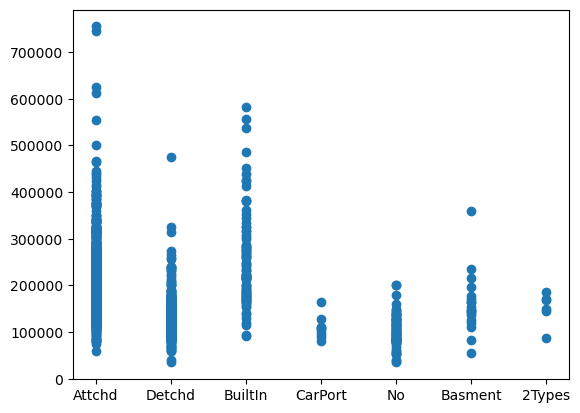

In [85]:
# Plot a scatterplot to get the visualation of the feature 

plt.scatter(x = 'GarageType', y = 'SalePrice', data = TrainDF_HousingData)

## GarageFinish Feature

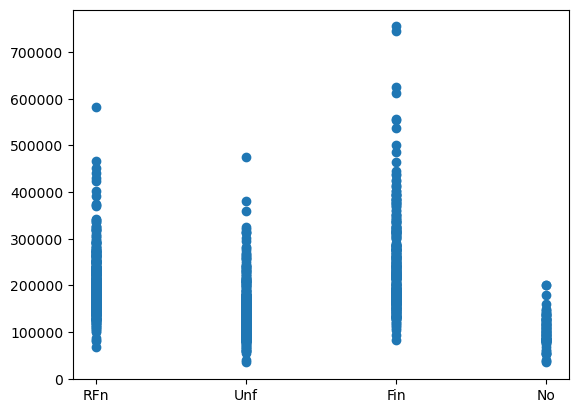

In [86]:
plt.scatter(x = 'GarageFinish', y = 'SalePrice', data = TrainDF_HousingData)

## GarageQual Feature

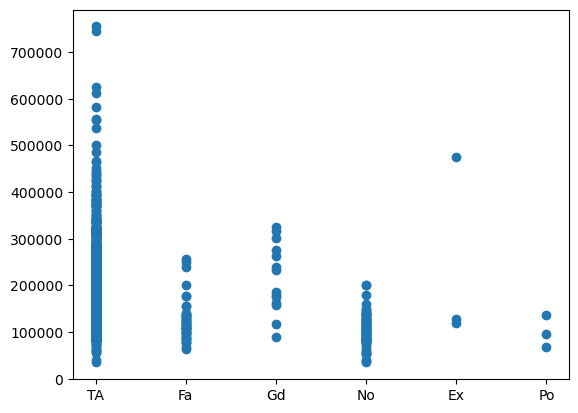

In [87]:
plt.scatter(x = 'GarageQual', y = 'SalePrice', data = TrainDF_HousingData)

## GarageCond Feature

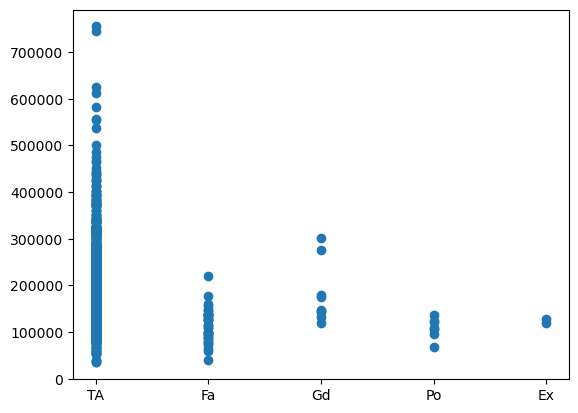

In [88]:
plt.scatter(x = 'GarageCond', y = 'SalePrice', data = TrainDF_HousingData)

## MasVnrArea Feature

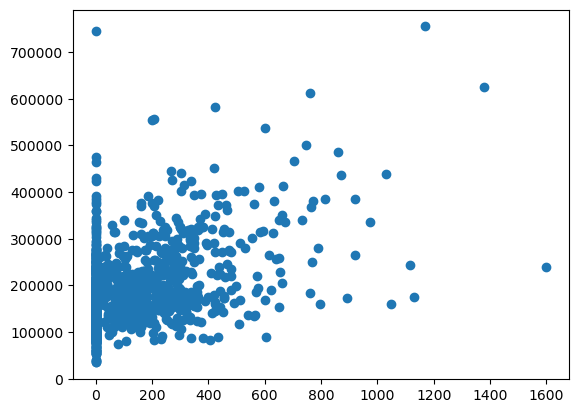

In [89]:
plt.scatter(x = 'MasVnrArea', y = 'SalePrice', data = TrainDF_HousingData)

In [90]:
# Manual way to find out the outliers

Mean = TrainDF_HousingData.MasVnrArea.mean()
SD = TrainDF_HousingData.MasVnrArea.std()
Highest_Allowed_Value = Mean + (3*SD)
# 646.8838814696435
Lowest_Allowed_Value = Mean - (3*SD)
# -439.51335805366557

In [91]:
TrainDF_HousingData.query('MasVnrArea > 1500')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
297,298,60,FV,66.0,7399,Pave,IR1,Lvl,AllPub,Inside,...,0,0,198,0,0,6,2007,WD,Normal,239000


In [92]:
TrainDF_HousingData.query('MasVnrArea > 646.8838814696435').head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
37,38,20,RL,74.0,8532,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,10,2009,WD,Normal,153000
58,59,60,RL,66.0,13682,Pave,IR2,HLS,AllPub,CulDSac,...,37,0,0,0,0,10,2006,New,Partial,438780
70,71,20,RL,95.0,13651,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2007,WD,Normal,244000


## BsmtExposure Feature

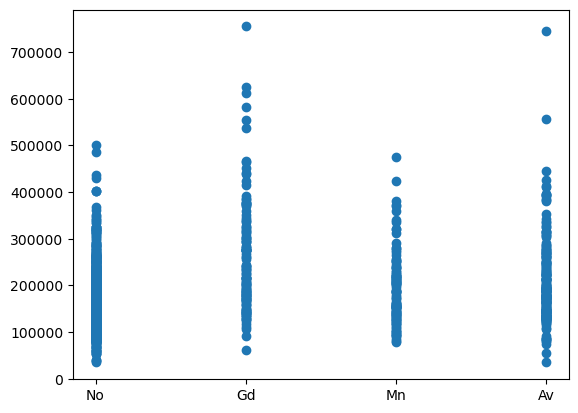

In [93]:
plt.scatter(x = 'BsmtExposure', y = 'SalePrice', data = TrainDF_HousingData)

## BsmtFinType1 Feature

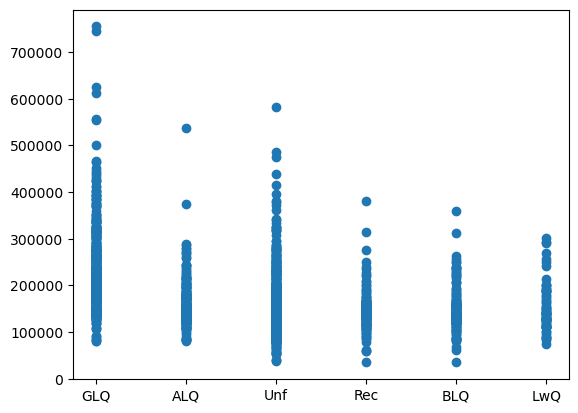

In [94]:
plt.scatter(x = 'BsmtFinType1', y = 'SalePrice', data = TrainDF_HousingData)

## BsmtFinType2 Feature

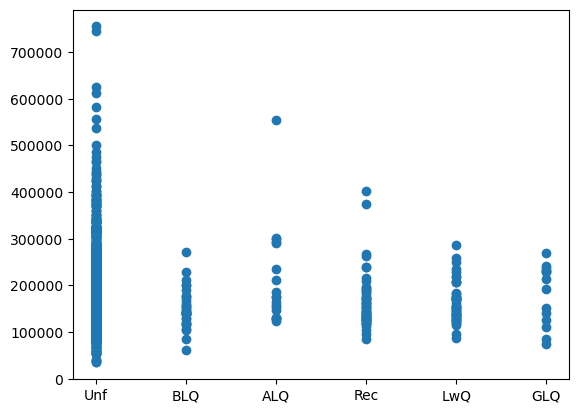

In [95]:
plt.scatter(x = 'BsmtFinType2', y = 'SalePrice', data = TrainDF_HousingData)

## Utilities Feature

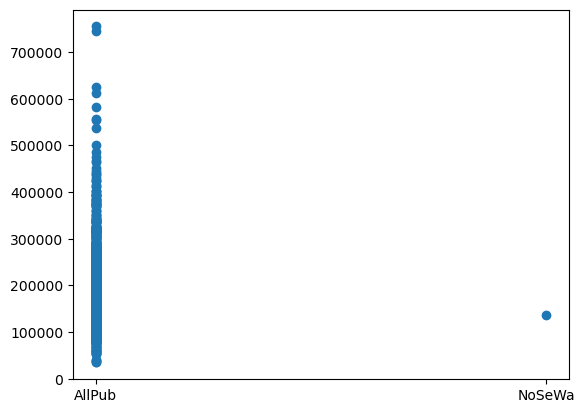

In [96]:
plt.scatter(x = 'Utilities', y = 'SalePrice', data = TrainDF_HousingData)

## Exterior1st Feature

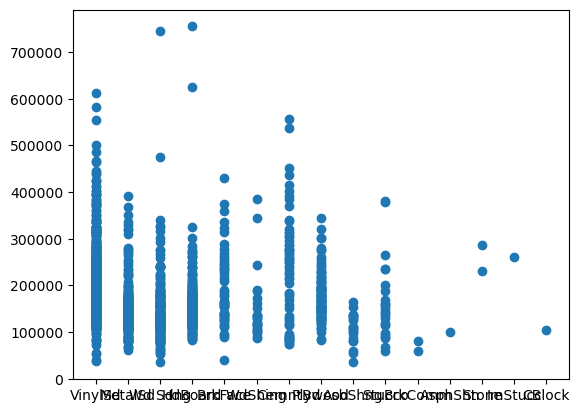

In [97]:
plt.scatter(x = 'Exterior1st', y = 'SalePrice', data = TrainDF_HousingData)

## Exterior2nd Feature

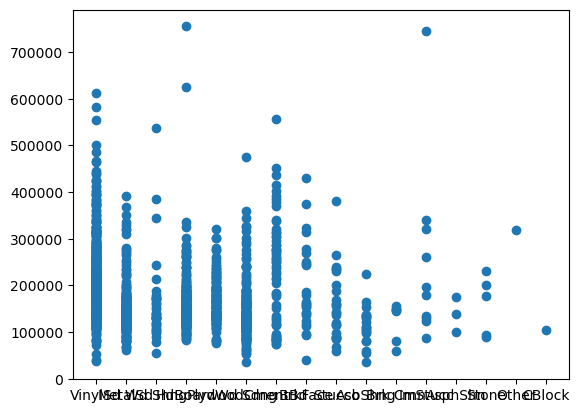

In [98]:
plt.scatter(x = 'Exterior2nd', y = 'SalePrice', data = TrainDF_HousingData)

## BsmtFinSF1 Feature

In [99]:
TrainDF_HousingData.BsmtFinSF1.min()

0

In [100]:
TrainDF_HousingData.BsmtFinSF1.max()

5644

In [101]:
sum(TrainDF_HousingData.BsmtFinSF1.isnull())

0

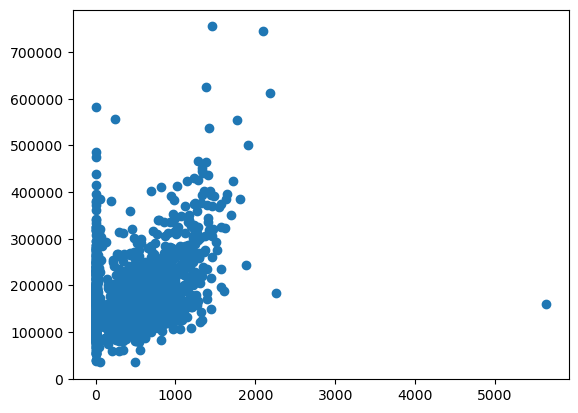

In [102]:
plt.scatter(x = 'BsmtFinSF1', y = 'SalePrice', data = TrainDF_HousingData)

In [103]:
TrainDF_HousingData.query('BsmtFinSF1 > 3000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,...,0,0,0,480,0,1,2008,New,Partial,160000


## BsmtFinSF2 Feature

In [104]:
TrainDF_HousingData.BsmtFinSF2.min()

0

In [105]:
TrainDF_HousingData.BsmtFinSF2.max()

1474

In [106]:
sum(TrainDF_HousingData.BsmtFinSF2.isnull())

0

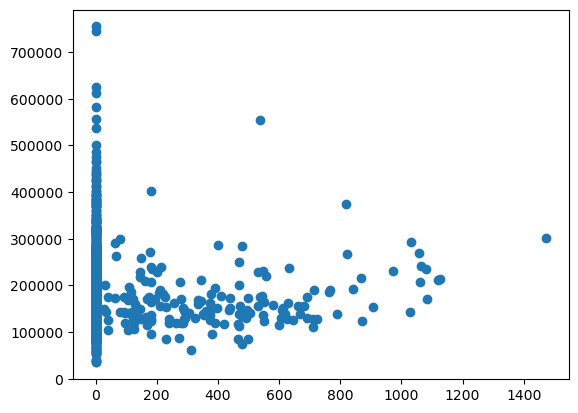

In [107]:
plt.scatter(x = 'BsmtFinSF2', y = 'SalePrice', data = TrainDF_HousingData)

In [108]:
TrainDF_HousingData.query('BsmtFinSF2 > 400 and SalePrice > 500000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
440,441,20,RL,105.0,15431,Pave,Reg,Lvl,AllPub,Inside,...,0,0,170,0,0,4,2009,WD,Normal,555000


## BsmtUnfSF Feature

In [109]:
TrainDF_HousingData.BsmtUnfSF.min()

0

In [110]:
TrainDF_HousingData.BsmtUnfSF.max()

2336

In [111]:
sum(TrainDF_HousingData.BsmtUnfSF.isnull())

0

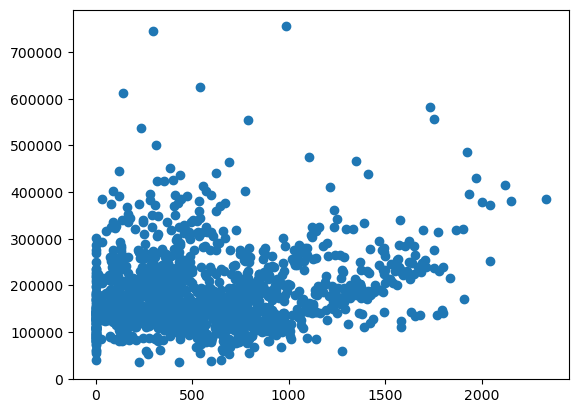

In [112]:
plt.scatter(x = 'BsmtUnfSF', y = 'SalePrice', data = TrainDF_HousingData)

## TotalBsmtSF Feature

In [113]:
TrainDF_HousingData.TotalBsmtSF.min()

0

In [114]:
TrainDF_HousingData.TotalBsmtSF.max()

6110

In [115]:
sum(TrainDF_HousingData.TotalBsmtSF.isnull())

0

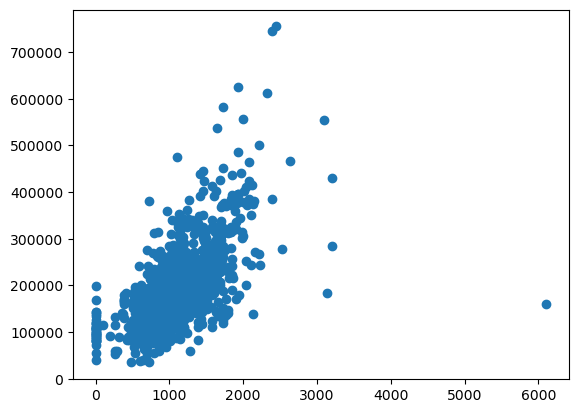

In [116]:
plt.scatter(x = 'TotalBsmtSF', y = 'SalePrice', data = TrainDF_HousingData)

In [117]:
TrainDF_HousingData.query('TotalBsmtSF > 3500')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1298,1299,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,...,0,0,0,480,0,1,2008,New,Partial,160000


## BsmtFullBath Feature

In [118]:
TrainDF_HousingData.BsmtFullBath.min()

0

In [119]:
TrainDF_HousingData.BsmtFullBath.max()

3

In [120]:
sum(TrainDF_HousingData.BsmtFullBath.isnull())

0

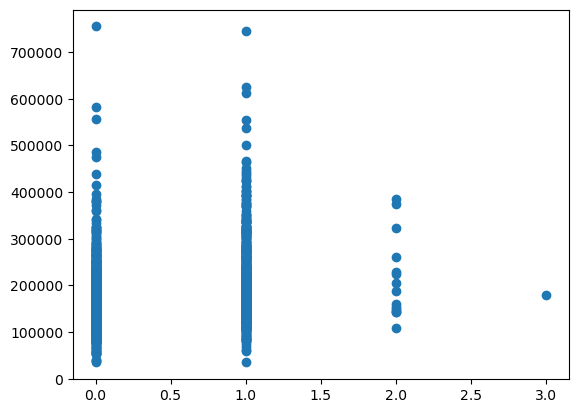

In [121]:
plt.scatter(x = 'BsmtFullBath', y = 'SalePrice', data = TrainDF_HousingData)

In [122]:
TrainDF_HousingData.query('BsmtFullBath == 3')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
738,739,90,RL,60.0,10800,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,3,2009,WD,Alloca,179000


In [123]:
TrainDF_HousingData.BsmtFullBath.value_counts()

BsmtFullBath
0    856
1    588
2     15
3      1
Name: count, dtype: int64

## BsmtHalfBath Feature

In [124]:
TrainDF_HousingData.BsmtHalfBath.min()

0

In [125]:
TrainDF_HousingData.BsmtHalfBath.max()

2

In [126]:
sum(TrainDF_HousingData.BsmtHalfBath.isnull())

0

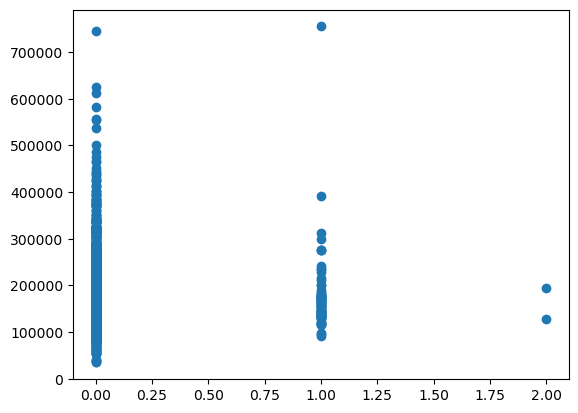

In [127]:
plt.scatter(x = 'BsmtHalfBath', y = 'SalePrice', data = TrainDF_HousingData)

In [128]:
np.unique(stats.zscore(TrainDF_HousingData['BsmtHalfBath']))

array([-0.24106104,  3.94880935,  8.13867973])

In [129]:
TrainDF_HousingData.query('BsmtHalfBath == 2')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
597,598,120,RL,53.0,3922,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2007,New,Partial,194201
954,955,90,RL,35.0,9400,Pave,IR1,Lvl,AllPub,CulDSac,...,0,0,0,0,0,10,2006,WD,AdjLand,127500


In [130]:
TrainDF_HousingData.BsmtHalfBath.value_counts()

BsmtHalfBath
0    1378
1      80
2       2
Name: count, dtype: int64

## KitchenQual Feature

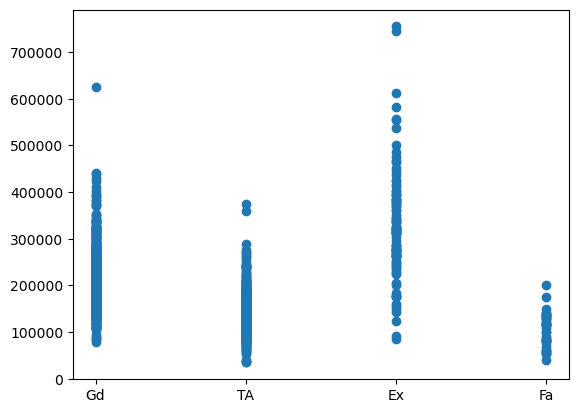

In [131]:
plt.scatter(x = 'KitchenQual', y = 'SalePrice', data = TrainDF_HousingData)

## Functional Feature

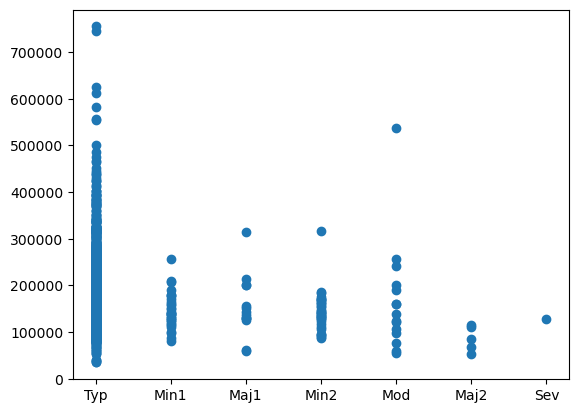

In [132]:
plt.scatter(x = 'Functional', y = 'SalePrice', data = TrainDF_HousingData)

## GarageCars Feature

In [133]:
sum(TrainDF_HousingData.GarageCars.isnull())

0

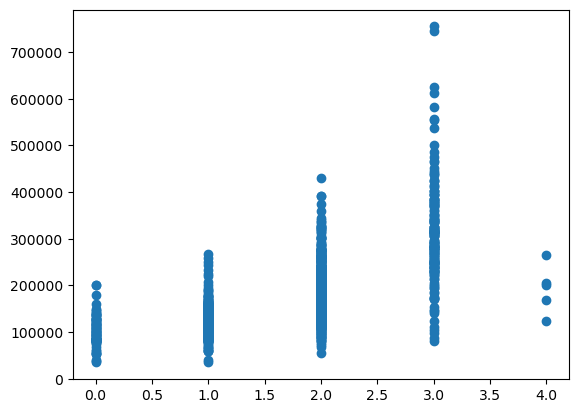

In [134]:
plt.scatter(x = 'GarageCars', y = 'SalePrice', data = TrainDF_HousingData)

## GarageArea Feature

In [135]:
TrainDF_HousingData.GarageArea.min()

0

In [136]:
TrainDF_HousingData.GarageArea.max()

1418

In [137]:
sum(TrainDF_HousingData.GarageArea.isnull())

0

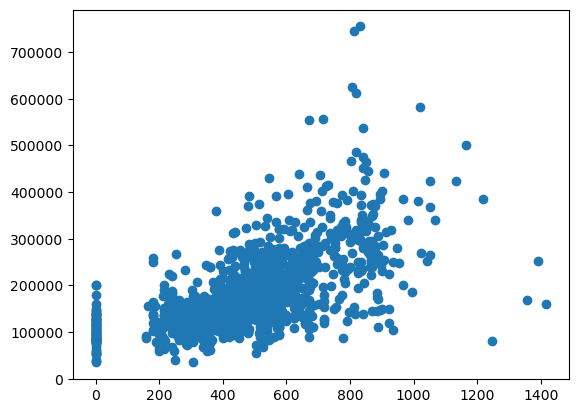

In [138]:
plt.scatter(x = 'GarageArea', y = 'SalePrice', data = TrainDF_HousingData)

In [139]:
TrainDF_HousingData.query('GarageArea > 1200')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
581,582,20,RL,98.0,12704,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2009,New,Partial,253293
825,826,20,RL,114.0,14803,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,6,2008,New,Partial,385000
1061,1062,30,C (all),120.0,18000,Grvl,Reg,Low,AllPub,Inside,...,0,0,0,0,560,8,2008,ConLD,Normal,81000
1190,1191,190,RL,0.0,32463,Pave,Reg,Low,AllPub,Inside,...,0,0,0,0,0,3,2007,WD,Normal,168000
1298,1299,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,...,0,0,0,480,0,1,2008,New,Partial,160000


## SaleType Feature

<Axes: xlabel='SaleType', ylabel='SalePrice'>

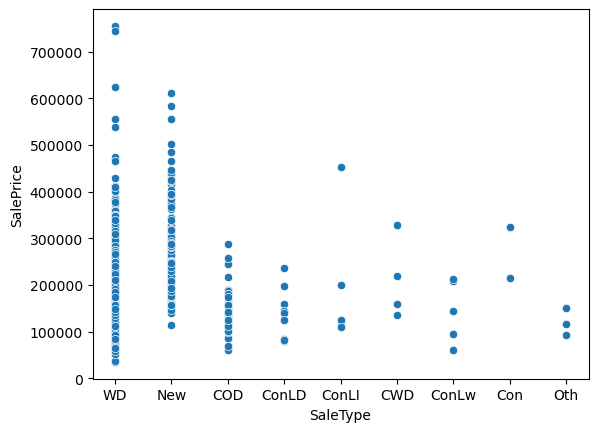

In [140]:
sns.scatterplot(x = 'SaleType', y = 'SalePrice', data = TrainDF_HousingData)

## OverallQual Feature

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

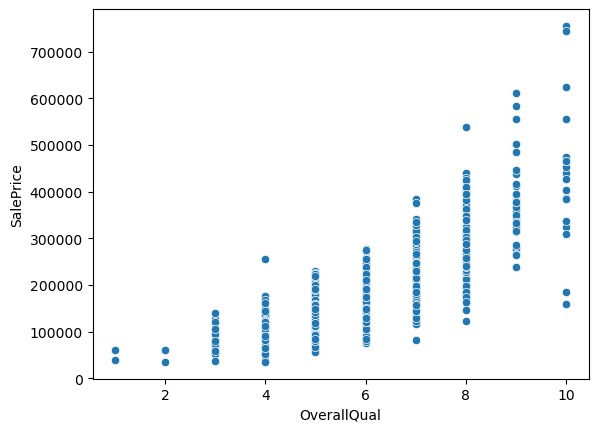

In [141]:
sns.scatterplot(x = 'OverallQual', y = 'SalePrice', data = TrainDF_HousingData)

In [142]:
TrainDF_HousingData.query('OverallQual == 10 and SalePrice < 200000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,IR1,Bnk,AllPub,Inside,...,0,0,0,0,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,...,0,0,0,480,0,1,2008,New,Partial,160000


## OverallCond Feature

In [143]:
sum(TrainDF_HousingData.OverallCond.isnull())

0

In [144]:
TrainDF_HousingData.OverallCond.value_counts()

OverallCond
5    821
6    252
7    205
8     72
4     57
3     25
9     22
2      5
1      1
Name: count, dtype: int64

<Axes: xlabel='OverallCond', ylabel='SalePrice'>

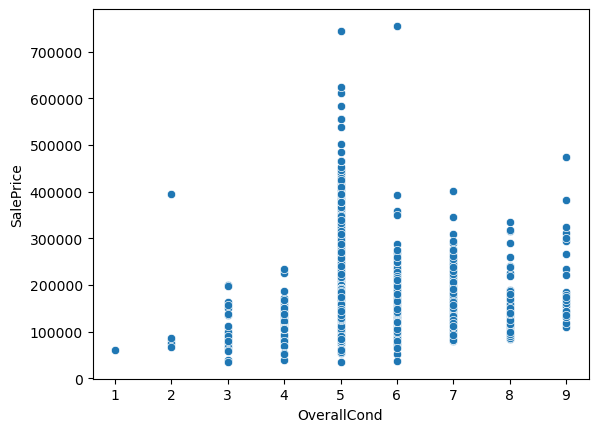

In [145]:
sns.scatterplot(x = 'OverallCond', y = 'SalePrice', data = TrainDF_HousingData)

In [146]:
TrainDF_HousingData.query('OverallCond == 2 and SalePrice > 300000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
378,379,20,RL,88.0,11394,Pave,Reg,Lvl,AllPub,Corner,...,0,0,0,0,0,6,2010,New,Partial,394432


In [147]:
TrainDF_HousingData.query('OverallCond == 5 and SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1182,1183,60,RL,160.0,15623,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,555,0,7,2007,WD,Abnorml,745000


In [148]:
TrainDF_HousingData.query('OverallCond == 6 and SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,0,0,1,2007,WD,Normal,755000


## YearBuilt Feature

In [149]:
TrainDF_HousingData.YearBuilt.min()

1872

In [150]:
TrainDF_HousingData.YearBuilt.max()

2010

In [151]:
sum(TrainDF_HousingData.YearBuilt.isnull())

0

<Axes: xlabel='YearBuilt', ylabel='SalePrice'>

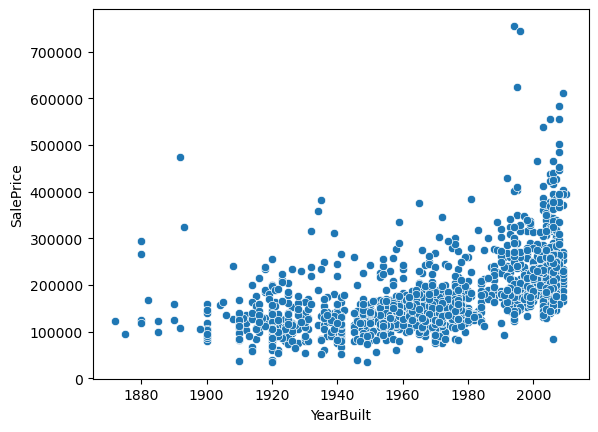

In [152]:
sns.scatterplot(x = 'YearBuilt', y = 'SalePrice', data = TrainDF_HousingData)

In [153]:
TrainDF_HousingData.query('YearBuilt < 1900 and SalePrice > 400000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,IR2,Lvl,AllPub,Inside,...,0,0,410,0,0,6,2006,WD,Normal,475000


## YearRemodAdd Feature

In [154]:
TrainDF_HousingData.YearRemodAdd.min()

1950

In [155]:
TrainDF_HousingData.YearRemodAdd.max()

2010

In [156]:
sum(TrainDF_HousingData.YearRemodAdd.isnull())

0

<Axes: xlabel='YearRemodAdd', ylabel='SalePrice'>

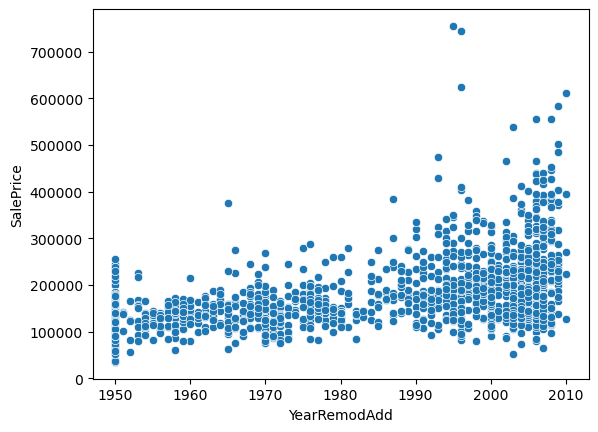

In [157]:
sns.scatterplot(x = 'YearRemodAdd', y = 'SalePrice', data = TrainDF_HousingData)

In [158]:
TrainDF_HousingData.query('YearRemodAdd > 1990 and SalePrice > 700000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
691,692,60,RL,104.0,21535,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,0,0,1,2007,WD,Normal,755000
1182,1183,60,RL,160.0,15623,Pave,IR1,Lvl,AllPub,Corner,...,0,0,0,555,0,7,2007,WD,Abnorml,745000


## 1stFlrSF Feature

In [159]:
TrainDF_HousingData['1stFlrSF'].min()

334

In [160]:
TrainDF_HousingData['1stFlrSF'].max()

4692

In [161]:
sum(TrainDF_HousingData['1stFlrSF'].isnull())

0

<Axes: xlabel='1stFlrSF', ylabel='SalePrice'>

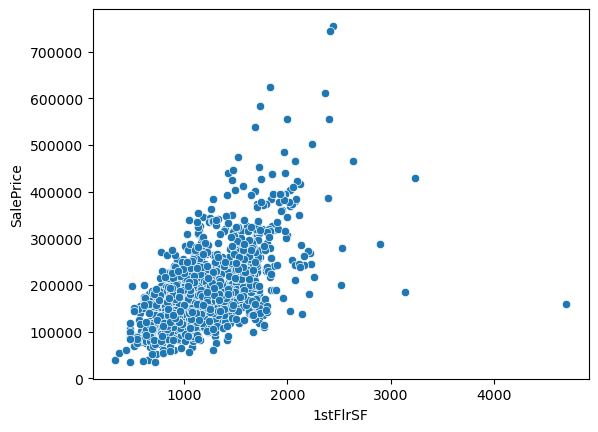

In [162]:
sns.scatterplot(x = '1stFlrSF', y = 'SalePrice', data = TrainDF_HousingData)

## 2ndFlrSF Feature

In [163]:
TrainDF_HousingData['2ndFlrSF'].min()

0

In [164]:
TrainDF_HousingData['2ndFlrSF'].max()

2065

In [165]:
sum(TrainDF_HousingData['2ndFlrSF'].isnull())

0

<Axes: xlabel='2ndFlrSF', ylabel='SalePrice'>

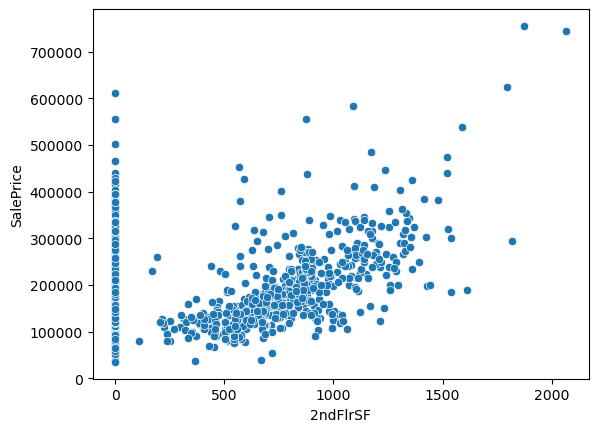

In [166]:
sns.scatterplot(x = '2ndFlrSF', y = 'SalePrice', data = TrainDF_HousingData)

## LowQualFinSF Feature

<Axes: xlabel='LowQualFinSF', ylabel='SalePrice'>

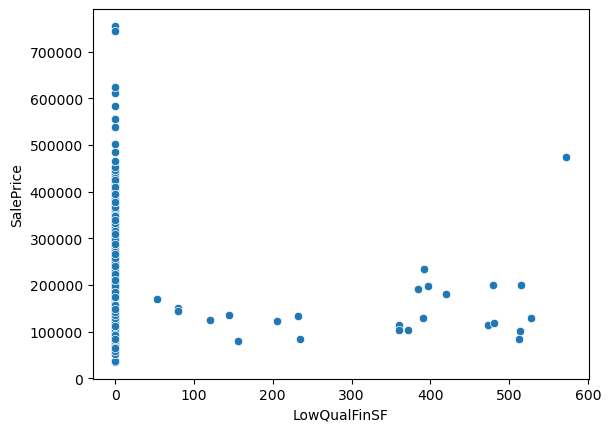

In [167]:
sns.scatterplot(x = 'LowQualFinSF', y = 'SalePrice', data = TrainDF_HousingData)

In [168]:
TrainDF_HousingData.query('LowQualFinSF > 500 and SalePrice > 400000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
185,186,75,RM,90.0,22950,Pave,IR2,Lvl,AllPub,Inside,...,0,0,410,0,0,6,2006,WD,Normal,475000


## GrLivArea Feature

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

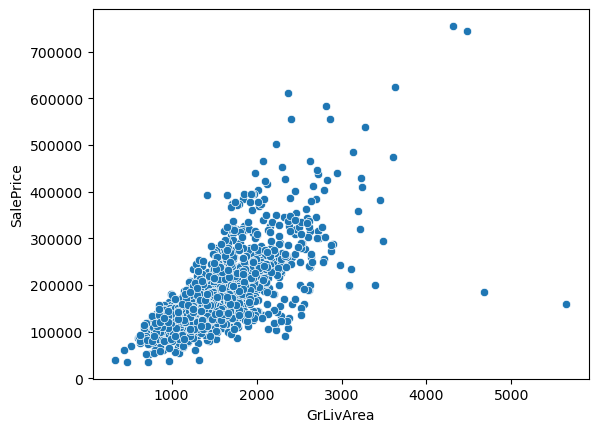

In [169]:
sns.scatterplot(x = 'GrLivArea', y = 'SalePrice', data = TrainDF_HousingData)

In [170]:
TrainDF_HousingData.query('GrLivArea > 4000 and SalePrice < 300000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,IR1,Bnk,AllPub,Inside,...,0,0,0,0,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,IR3,Bnk,AllPub,Corner,...,0,0,0,480,0,1,2008,New,Partial,160000


## FullBath Feature

<Axes: xlabel='FullBath', ylabel='SalePrice'>

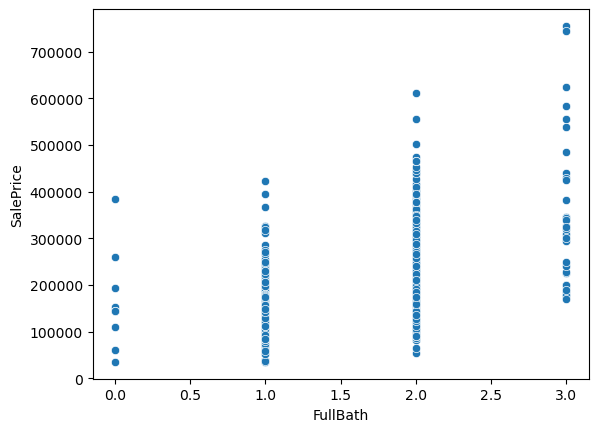

In [171]:
sns.scatterplot(x = 'FullBath', y = 'SalePrice', data = TrainDF_HousingData)

## HalfBath Feature

<Axes: xlabel='HalfBath', ylabel='SalePrice'>

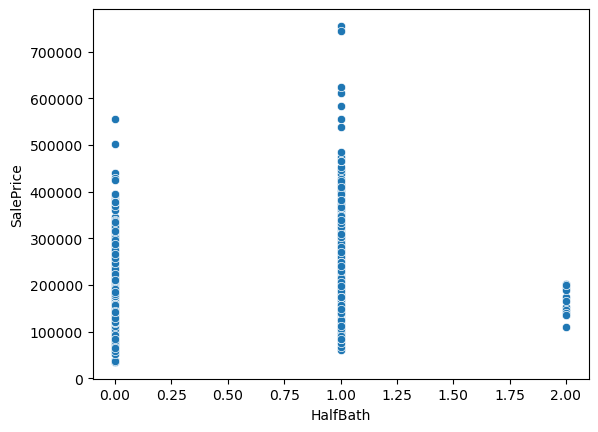

In [172]:
sns.scatterplot(x = 'HalfBath', y = 'SalePrice', data = TrainDF_HousingData)

## BedroomAbvGr Feature

<Axes: xlabel='BedroomAbvGr', ylabel='SalePrice'>

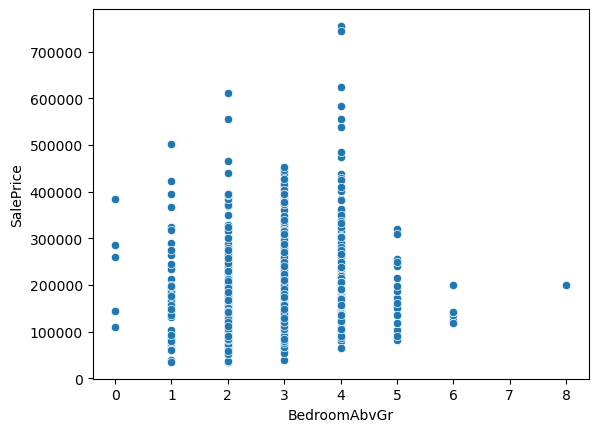

In [173]:
sns.scatterplot(x = 'BedroomAbvGr', y = 'SalePrice', data = TrainDF_HousingData)

In [174]:
np.unique(stats.zscore(TrainDF_HousingData.BedroomAbvGr))

array([-3.51495182, -2.28870817, -1.06246453,  0.16377912,  1.39002276,
        2.61626641,  3.84251005,  6.29499734])

In [175]:
TrainDF_HousingData.query('BedroomAbvGr == 8')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Reg,Bnk,AllPub,Inside,...,0,0,0,0,0,3,2007,WD,Abnorml,200000


## KitchenAbvGr Featur

<Axes: xlabel='KitchenAbvGr', ylabel='SalePrice'>

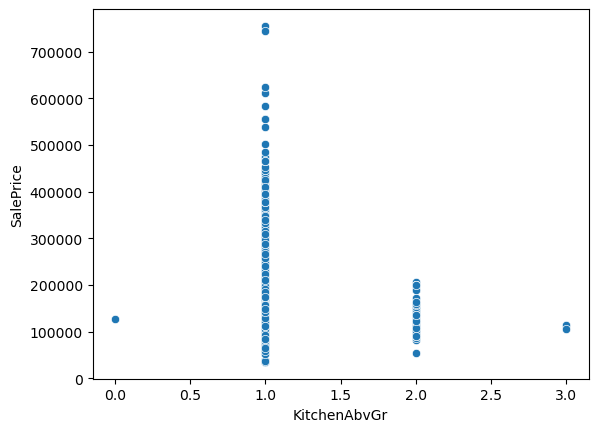

In [176]:
sns.scatterplot(x = 'KitchenAbvGr', y = 'SalePrice', data = TrainDF_HousingData)

In [177]:
TrainDF_HousingData.query('KitchenAbvGr == 0')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
954,955,90,RL,35.0,9400,Pave,IR1,Lvl,AllPub,CulDSac,...,0,0,0,0,0,10,2006,WD,AdjLand,127500


In [178]:
TrainDF_HousingData.query('KitchenAbvGr == 3')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
48,49,190,RM,33.0,4456,Pave,Reg,Lvl,AllPub,Inside,...,102,0,0,0,0,6,2009,New,Partial,113000
809,810,75,RM,90.0,8100,Pave,Reg,Lvl,AllPub,Corner,...,0,0,0,0,0,11,2009,WD,Normal,106000


## TotRmsAbvGrd

<Axes: xlabel='TotRmsAbvGrd', ylabel='SalePrice'>

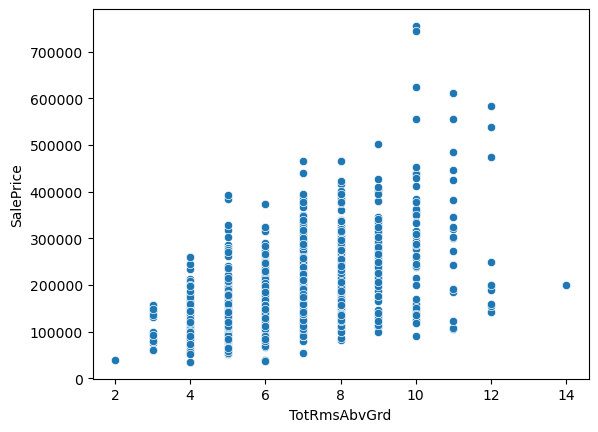

In [179]:
sns.scatterplot(x = 'TotRmsAbvGrd', y = 'SalePrice', data = TrainDF_HousingData)

In [180]:
TrainDF_HousingData.query('TotRmsAbvGrd == 14')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
635,636,190,RH,60.0,10896,Pave,Reg,Bnk,AllPub,Inside,...,0,0,0,0,0,3,2007,WD,Abnorml,200000


## Fireplaces

<Axes: xlabel='Fireplaces', ylabel='SalePrice'>

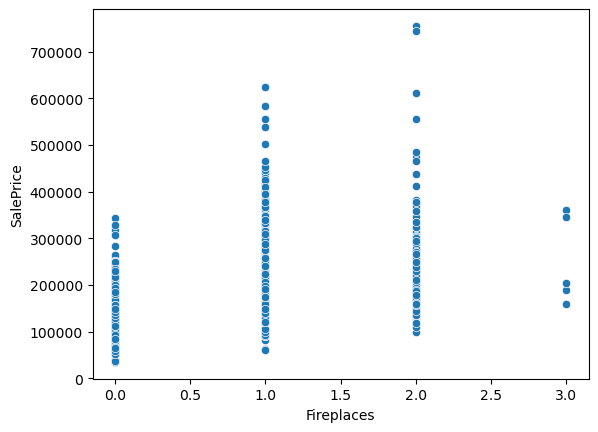

In [181]:
sns.scatterplot(x = 'Fireplaces', y = 'SalePrice', data = TrainDF_HousingData)

## WoodDeckSF Feature

<Axes: xlabel='WoodDeckSF', ylabel='SalePrice'>

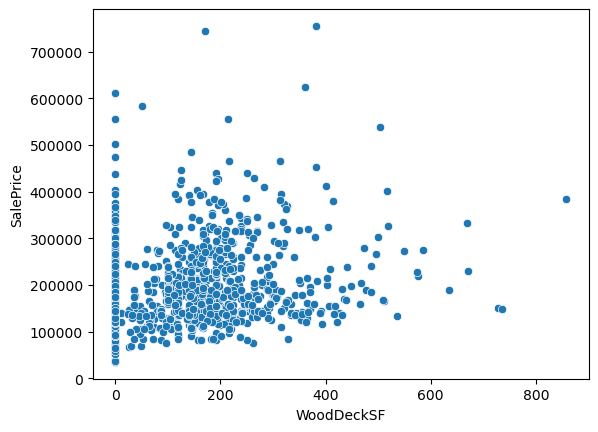

In [182]:
sns.scatterplot(x = 'WoodDeckSF', y = 'SalePrice', data = TrainDF_HousingData)

In [183]:
TrainDF_HousingData.query('WoodDeckSF == 14')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice


## OpenPorchSF Feature

<Axes: xlabel='OpenPorchSF', ylabel='SalePrice'>

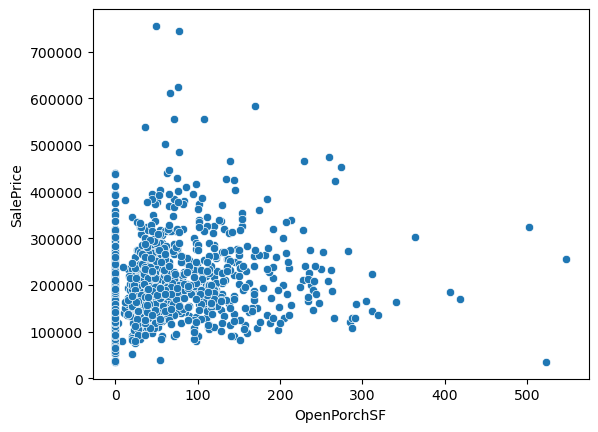

In [184]:
sns.scatterplot(x = 'OpenPorchSF', y = 'SalePrice', data = TrainDF_HousingData)

In [185]:
TrainDF_HousingData.query('OpenPorchSF > 500 and SalePrice < 100000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
495,496,30,C (all),60.0,7879,Pave,Reg,Lvl,AllPub,Inside,...,115,0,0,0,0,11,2009,WD,Abnorml,34900


## EnclosedPorch Feature

<Axes: xlabel='EnclosedPorch', ylabel='SalePrice'>

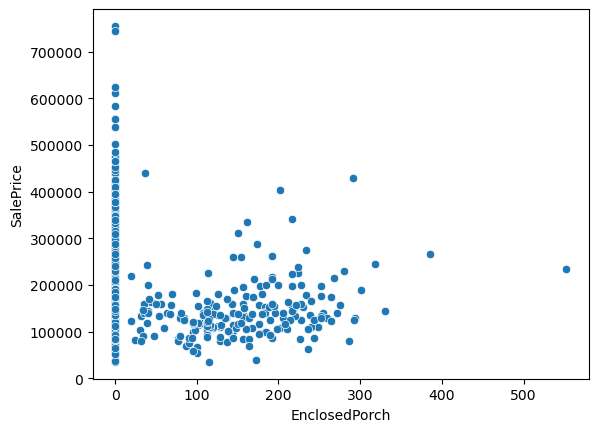

In [186]:
sns.scatterplot(x = 'EnclosedPorch', y = 'SalePrice', data = TrainDF_HousingData)

In [187]:
TrainDF_HousingData.query('EnclosedPorch > 500')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
197,198,75,RL,174.0,25419,Pave,Reg,Lvl,AllPub,Corner,...,552,0,0,512,0,3,2006,WD,Abnorml,235000


## 3SsnPorch Feature

<Axes: xlabel='3SsnPorch', ylabel='SalePrice'>

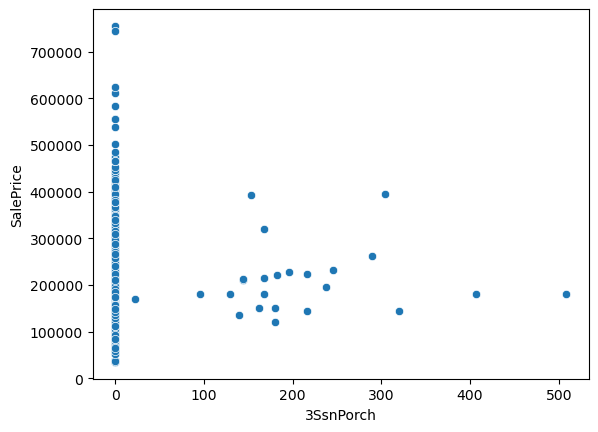

In [188]:
sns.scatterplot(x = '3SsnPorch', y = 'SalePrice', data = TrainDF_HousingData)

## ScreenPorch Feature

<Axes: xlabel='ScreenPorch', ylabel='SalePrice'>

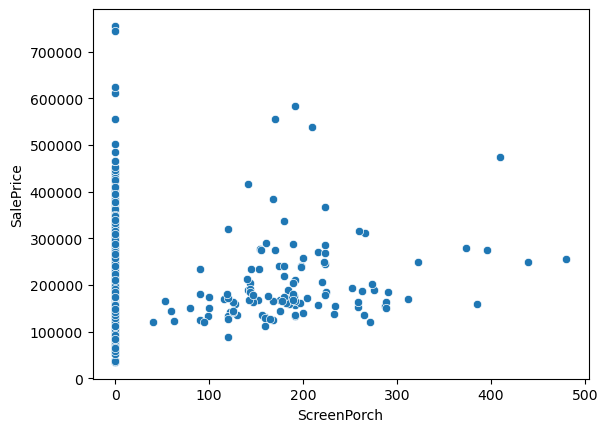

In [189]:
sns.scatterplot(x = 'ScreenPorch', y = 'SalePrice', data = TrainDF_HousingData)

## PoolArea Feature

<Axes: xlabel='PoolArea', ylabel='SalePrice'>

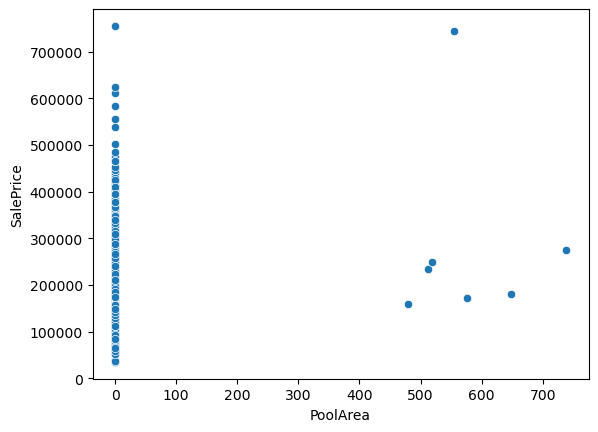

In [190]:
sns.scatterplot(x = 'PoolArea', y = 'SalePrice', data = TrainDF_HousingData)

## MiscVal Feature

<Axes: xlabel='MiscVal', ylabel='SalePrice'>

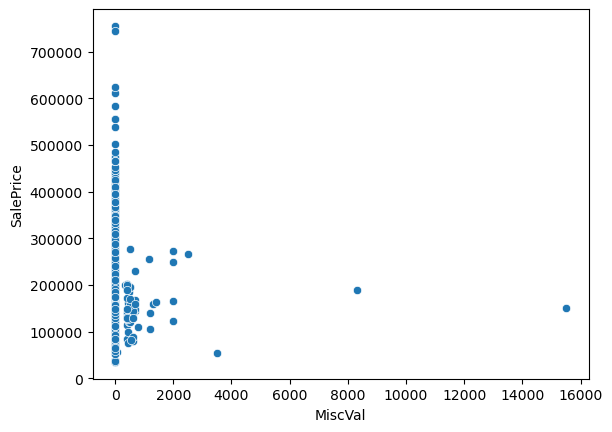

In [191]:
sns.scatterplot(x = 'MiscVal', y = 'SalePrice', data = TrainDF_HousingData)

In [192]:
TrainDF_HousingData.query('MiscVal >8000')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
346,347,20,RL,0.0,12772,Pave,IR1,Lvl,AllPub,CulDSac,...,0,0,0,0,15500,4,2007,WD,Normal,151500
1230,1231,90,RL,0.0,18890,Pave,IR1,Lvl,AllPub,Inside,...,145,0,0,0,8300,8,2007,WD,Normal,190000


## MoSold Feature

<Axes: xlabel='MoSold', ylabel='SalePrice'>

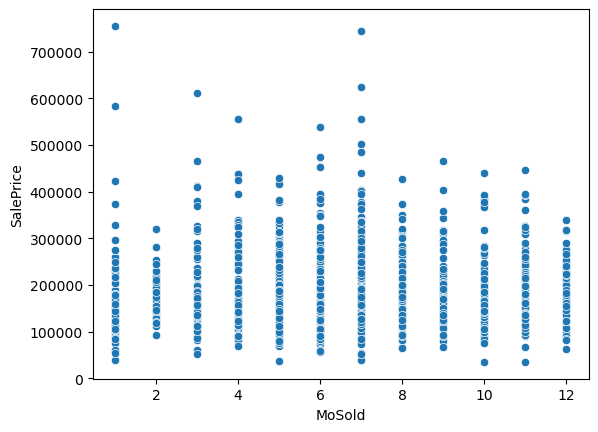

In [193]:
sns.scatterplot(x = 'MoSold', y = 'SalePrice', data = TrainDF_HousingData)

## YrSold Feature

<Axes: xlabel='YrSold', ylabel='SalePrice'>

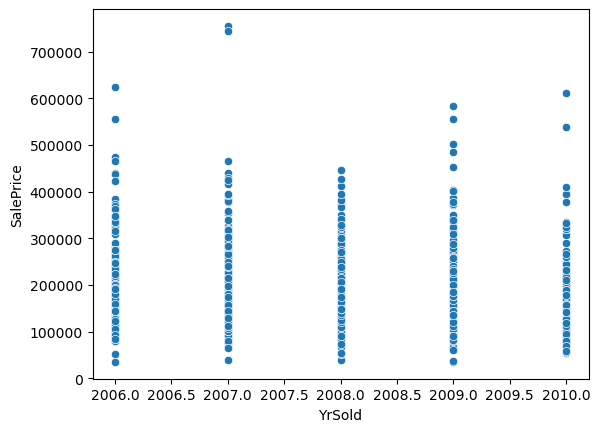

In [194]:
sns.scatterplot(x = 'YrSold', y = 'SalePrice', data = TrainDF_HousingData)

## Handling outliers

In [195]:
# Outliers - Drop

Outlier_Values = [49,  186,  198,  250,  298,  314,  336, 379, 441,  496,  524,  598, 636,  636,  692, 707,  739,  810,  935,  955, 1062, 1183, 1299]
TrainDF_HousingData = TrainDF_HousingData[TrainDF_HousingData.Id.isin(Outlier_Values) == False]

Outlier_Values = [49,  186,  198,  250,  298,  314,  336, 379, 441,  496,  524,  598, 636,  636,  692, 707,  739,  810,  935,  955, 1062, 1183, 1299]
TestDF_HousingData = TestDF_HousingData[TestDF_HousingData.Id.isin(Outlier_Values) == False]

## Feature Construction
- Create new features from the existing features.
- This will reduce the number of features we use for training the machine learning algorithm

In [196]:
TrainDF_HousingData['House_Age'] = TrainDF_HousingData['YrSold'] - TrainDF_HousingData['YearBuilt']
TestDF_HousingData['House_Age'] = TestDF_HousingData['YrSold'] - TestDF_HousingData['YearBuilt']

TrainDF_HousingData['House_Remodel_Age'] = TrainDF_HousingData['YrSold'] - TrainDF_HousingData['YearRemodAdd']
TestDF_HousingData['House_Remodel_Age'] = TestDF_HousingData['YrSold'] - TestDF_HousingData['YearRemodAdd']

TrainDF_HousingData['Total_Sqft'] = TrainDF_HousingData['1stFlrSF'] + TrainDF_HousingData['2ndFlrSF'] + TrainDF_HousingData['BsmtFinSF1'] \
+ TrainDF_HousingData['BsmtFinSF2']
TestDF_HousingData['Total_Sqft'] = TestDF_HousingData['1stFlrSF'] + TestDF_HousingData['2ndFlrSF'] + TestDF_HousingData['BsmtFinSF1'] \
+ TestDF_HousingData['BsmtFinSF2']

TrainDF_HousingData['Total_Area'] = TrainDF_HousingData['GrLivArea'] + TrainDF_HousingData['TotalBsmtSF']
TestDF_HousingData['Total_Area'] = TestDF_HousingData['GrLivArea'] + TestDF_HousingData['TotalBsmtSF']

TrainDF_HousingData['Total_Baths'] = TrainDF_HousingData['BsmtFullBath'] + TrainDF_HousingData['FullBath'] + 0.5 * (TrainDF_HousingData['BsmtHalfBath'] \
                                                                                                                    + TrainDF_HousingData['HalfBath'])
TestDF_HousingData['Total_Baths'] = TestDF_HousingData['BsmtFullBath'] + TestDF_HousingData['FullBath'] + 0.5 * (TestDF_HousingData['BsmtHalfBath'] \
                                                                                                                 + TestDF_HousingData['HalfBath'])

TrainDF_HousingData['Total_Porch_Sqft'] = TrainDF_HousingData['OpenPorchSF'] + TrainDF_HousingData['3SsnPorch'] + TrainDF_HousingData['EnclosedPorch'] \
+ TrainDF_HousingData['ScreenPorch'] + TrainDF_HousingData['WoodDeckSF']
TestDF_HousingData['Total_Porch_Sqft'] = TestDF_HousingData['OpenPorchSF'] + TestDF_HousingData['3SsnPorch'] + TestDF_HousingData['EnclosedPorch'] + \
TestDF_HousingData['ScreenPorch'] + TestDF_HousingData['WoodDeckSF']

In [197]:
# Remove the features used in Feature Construction - 18 original features are removed

TrainDF_HousingData = TrainDF_HousingData.drop(columns = ['YrSold','YearBuilt','YearRemodAdd','1stFlrSF','2ndFlrSF','BsmtFinSF1','BsmtFinSF2',\
                                                          'GrLivArea','TotalBsmtSF', 'BsmtFullBath','FullBath','BsmtHalfBath','HalfBath','OpenPorchSF',\
                                                          '3SsnPorch','EnclosedPorch','ScreenPorch','WoodDeckSF'])

TestDF_HousingData = TestDF_HousingData.drop(columns = ['YrSold','YearBuilt','YearRemodAdd','1stFlrSF','2ndFlrSF','BsmtFinSF1','BsmtFinSF2',\
                                                          'GrLivArea','TotalBsmtSF', 'BsmtFullBath','FullBath','BsmtHalfBath','HalfBath','OpenPorchSF',\
                                                          '3SsnPorch','EnclosedPorch','ScreenPorch','WoodDeckSF'])

In [198]:
# Drop - ID - unique identifier, no significance - drop this feature

TrainDF_HousingData.drop(['Id'],axis=1,inplace = True)
TestDF_HousingData.drop(['Id'],axis=1,inplace = True)

## CoRelation Analysis

<Axes: >

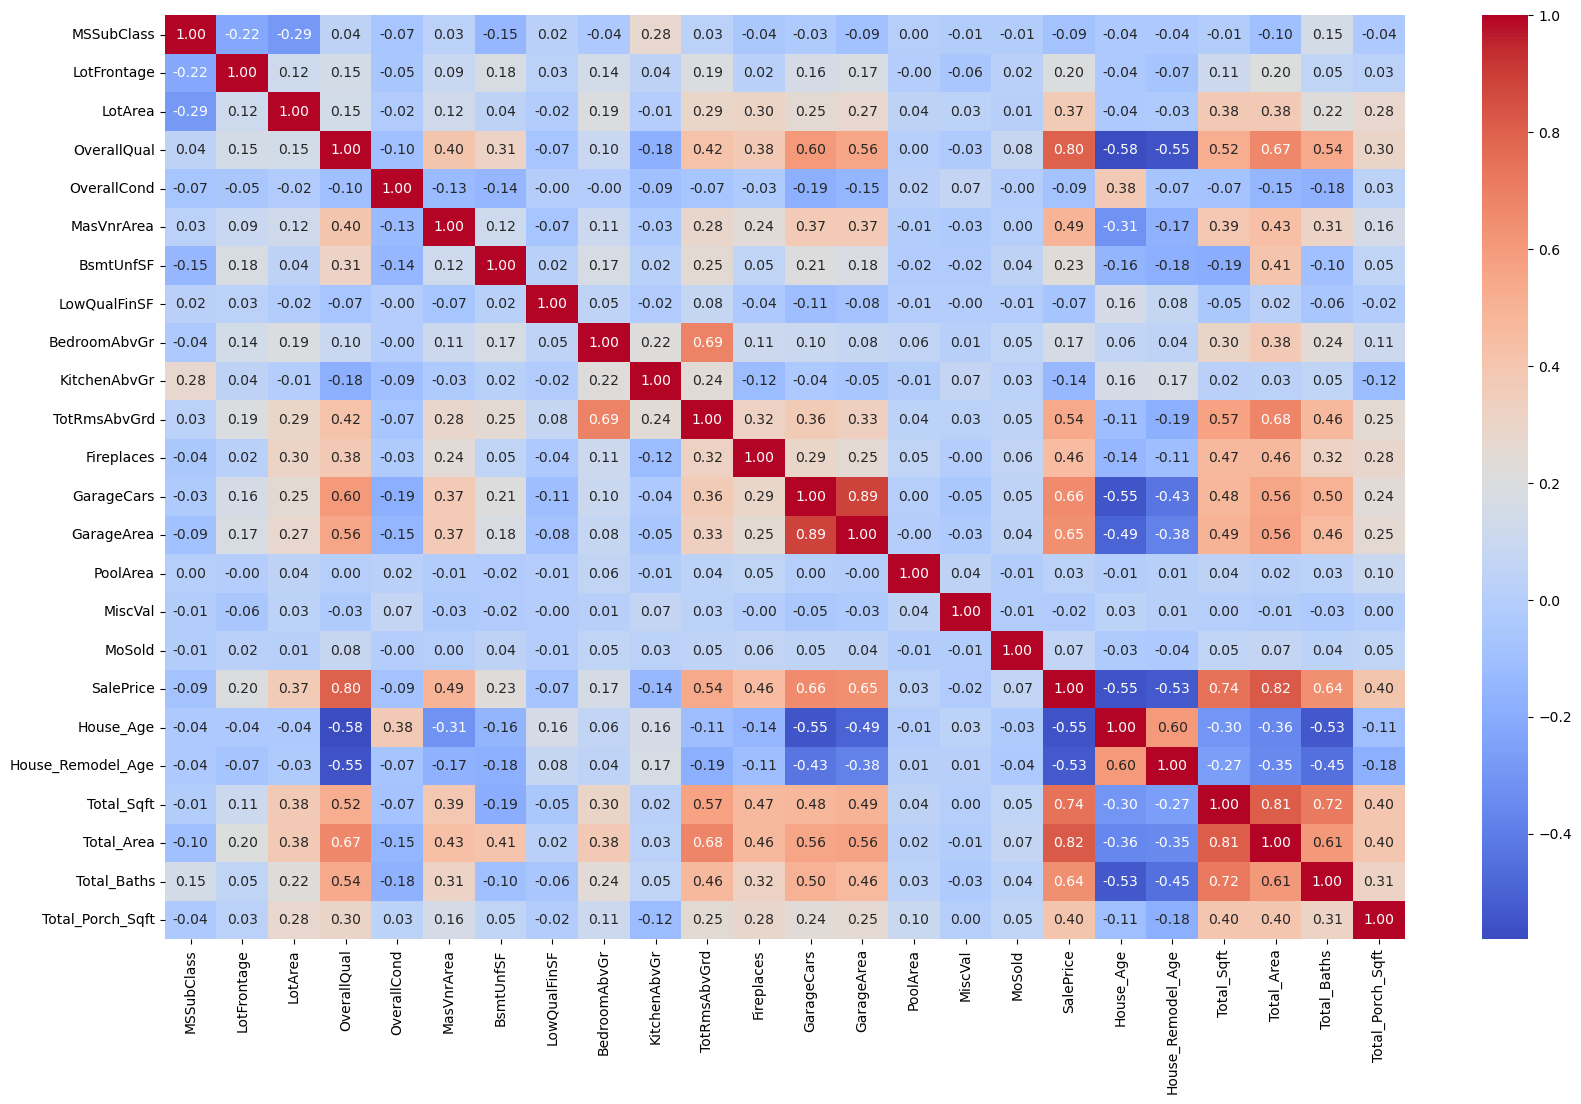

In [199]:
# CoRelation Matrix

correlation_matrix = TrainDF_HousingData.corr(numeric_only=True)
plt.figure(figsize=(20,12))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f')

In [200]:
# From above CoRelation Matrix, get the Features that are highly impacting the SalePrice, do not drop, these features are most 
# important in training the data

# OverallQual(0.8)
# TotalArea(0.82)
# TotalSqft (0.74)

In [201]:
# From above CoRelation Matrix, we can take Highly CoRelated Features - >= 80% and drop those features.

# GarageCars & GarageArea(0.89) >>> We can drop one of these Feature
# GarageCars - SalePrice (0.66)
# GarageArea - SalePrice(0.65)
TrainDF_HousingData.drop(['GarageArea'],axis=1,inplace = True)
TestDF_HousingData.drop(['GarageArea'],axis=1,inplace = True)

# TotalArea = TotalSqft (0.81)

<Axes: xlabel='SalePrice', ylabel='Count'>

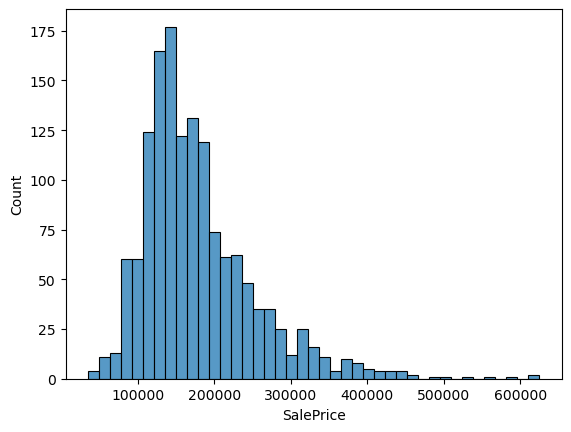

In [202]:
# Check the Skewness of the SalePrice Feature

sns.histplot(x=TrainDF_HousingData.SalePrice,data=TrainDF_HousingData)
#,bins=10)

In [203]:
# Data Transformations and Normalization: log1p is used for transforming data, especially when dealing with skewed distributions or values that are c
# lose to zero. It can help normalize data and make it more suitable for certain statistical models or algorithms.

TrainDF_HousingData['SalePrice'] = np.log1p(TrainDF_HousingData['SalePrice'])

<Axes: xlabel='SalePrice', ylabel='Count'>

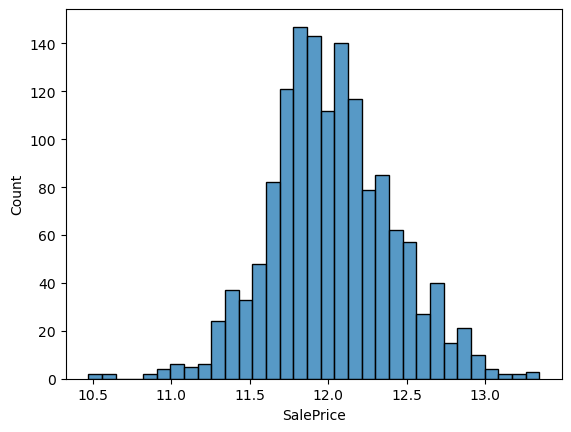

In [204]:
sns.histplot(x=TrainDF_HousingData.SalePrice,data=TrainDF_HousingData)

## Feature Encoding and Feature Scaling

### Feature Encoding
- Since ML algorithms are designed to work with numerical data, we need to convert non-numerical data to numeric, by performing encoding.

### Feature Scaling
- Perform Feature scaling to ensure that all features contribute equally to the model training process, preventing features with larger values from dominating the results.
- Since we might use XGB - gradient-based optimization, can be heavily influenced by features with larger values. Feature scaling ensures that no single feature inappropriately biases the model's learning process.

In [205]:
# Get the names of all the non numeric Features - We have to perform either One Hot Encoding or Ordinal Encoding depending on the type of data.
# Features that hold hierarchical data >>> Perform Ordinal encoding
# Features that do not have hierarchical data >>> Perform OneHotEncoding

Categorilcal_Features = TrainDF_HousingData.select_dtypes(include='object').columns
Categorilcal_Features

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [234]:
# Make a list of only those features that require Ordinal Encoding

Ordinal_Encoding_Features = ['LotShape', 'LandContour','Utilities','LandSlope',  'BsmtQual',  'BsmtFinType1', 'BsmtFinType2', 'CentralAir',  \
                             'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'PavedDrive', 'ExterCond', 'KitchenQual', 'BsmtExposure', \
                             'HeatingQC','ExterQual', 'BsmtCond','GarageCond']

In [235]:
# Make a list of only those features that require OneHot Encoding

OneHot_Encoding_Features = ['Street', 'LotConfig','Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', \
                  'Exterior2nd', 'MasVnrType','Foundation',  'Electrical',  'SaleType', 'MSZoning', 'SaleCondition', 'Heating', 'GarageType', \
                  'RoofMatl']

In [236]:
# Get all the numeric Features - as we have to perform scaling

Numerical_Features = TrainDF_HousingData.select_dtypes(include=['int64','float64']).columns
Numerical_Features

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'MasVnrArea', 'BsmtUnfSF', 'LowQualFinSF', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'PoolArea',
       'MiscVal', 'MoSold', 'SalePrice', 'House_Age', 'House_Remodel_Age',
       'Total_Sqft', 'Total_Area', 'Total_Baths', 'Total_Porch_Sqft'],
      dtype='object')

In [237]:
# Remove the output Feature - SalePrice from the Scaling list

Numerical_Features = Numerical_Features.drop(['SalePrice'])
Numerical_Features

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'MasVnrArea', 'BsmtUnfSF', 'LowQualFinSF', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'PoolArea',
       'MiscVal', 'MoSold', 'House_Age', 'House_Remodel_Age', 'Total_Sqft',
       'Total_Area', 'Total_Baths', 'Total_Porch_Sqft'],
      dtype='object')

### Create Pipeline for numerical and categorical features

In [238]:
# Create a pipeline for numerical features - to perform imputing with mean and then to perform Standard Scaling

Numerical_Features_PipelineObj = Pipeline(steps = [
    ('Imputer_NumMean',SimpleImputer(strategy='mean')),
    ('StandardScaler',StandardScaler()) # X_scaled = (X - mean) / standard_deviation.
])

In [239]:
# Create a pipeline for Ordinal features - to perform imputing with mode and then to perform Ordinal Encoding

Ordinal_Encoding_Features_PipelineObj = Pipeline(steps = [
    ('Imputer_CatMode',SimpleImputer(strategy='most_frequent')),
    ('OrdinalEncoder',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

In [240]:
# Create a pipeline for Ordinal features - to perform imputing with mode and then to perform OneHot Encoding

OneHot_Encoding_Features_PipelineObj = Pipeline(steps = [
    ('CategoricalModeImputer',SimpleImputer(strategy='most_frequent')),
    ('OHE',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

### Column Transformers
- Mention the Column(Feature) Names and the type of action to be performed on each Feature

In [241]:
# Now provide the list of Columns and the respective action to be performed on each of those columns.

ColumnTransformer_Obj = ColumnTransformer(transformers=[
    ('NumTransPip',Numerical_Features_PipelineObj,Numerical_Features),
    ('OrdTransPip',Ordinal_Encoding_Features_PipelineObj,Ordinal_Encoding_Features),
    ('OHETransPip',OneHot_Encoding_Features_PipelineObj,OneHot_Encoding_Features)
], remainder='passthrough',n_jobs=-1)

# By default, only the specified columns in transformers are transformed and combined in the output, and the non-specified columns are dropped. 
# hence use remainder='passthrough' to pass any unknown columns, instead of dropping them
# n_jobs = -1 >>> Number of jobs to run in parallel >>> -1 = Use all the available processors 

## Final Pipeline

In [242]:
Pipeline_AllCombined = Pipeline(steps = [
    ('FinalPreprocessingPipeline',ColumnTransformer_Obj)
])

## Prepare the data
- Get the input features
- Transform - preproces the input features before fitting to the ML Algorithm
- Get the output feature
- Prepare the train and test data

In [243]:
# Prepare the input and output dataset

X = TrainDF_HousingData.drop('SalePrice',axis=1)
y = TrainDF_HousingData['SalePrice']

In [244]:
# Send the input dataset for fit and transform
# This transforms all the numerical and categorical columns - Scaling, Encoding, Imputing

X_preprocessed = Pipeline_AllCombined.fit_transform(X)

### Check Later
- *********
- Apply PCA and see - check 3_PCA_Implementation_Sklearn
- This step is ignore for now...
- ***********

In [245]:
# Get the train and test data

X_train, X_test, y_train, y_test = train_test_split(X_preprocessed,y,test_size=0.2,random_state=25)

## Build and Test Various ML Models
- Build, predict and test various models

### Linear Regression

In [246]:
LinearRegression_Obj = LinearRegression()

In [247]:
LinearRegression_Obj.fit(X_train,y_train)

LinearRegression()

In [248]:
y_Predict_LinearRegression = LinearRegression_Obj.predict(X_test)

In [249]:
mean_squared_error(y_test, y_Predict_LinearRegression)

0.01197525679775234

### RandomForestRegressor

In [252]:
RandomForestRegressor_Obj = RandomForestRegressor(random_state=13)

In [253]:
ParamGrid_RandomForestRegressor = {
    'max_depth': [5,10,15],
    'n_estimators': [100,250,500],
    'min_samples_split': [3,5,10]
}

In [254]:
RandomForestRegressor_GridSearchCV_Obj = GridSearchCV(RandomForestRegressor_Obj, ParamGrid_RandomForestRegressor,
                                                     cv=5, scoring='neg_mean_squared_error',n_jobs=-1)

In [255]:
RandomForestRegressor_GridSearchCV_Obj.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=13), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_split': [3, 5, 10],
                         'n_estimators': [100, 250, 500]},
             scoring='neg_mean_squared_error')

In [256]:
y_Predict_RandomForestRegressor = RandomForestRegressor_GridSearchCV_Obj.predict(X_test)

In [257]:
mean_squared_error(y_test, y_Predict_RandomForestRegressor)

0.01746361938734153